**LIMPIEZA , TRANSFORMACION Y CREACION DE FEACTURES**

## 1. Importar Librerías y Cargar Datos


In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display

In [5]:
from pathlib import Path

customers = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_customers_dataset.csv")
items =  pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_items_dataset.csv")
payments =  pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_payments_dataset.csv")
reviews = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_reviews_dataset.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_orders_dataset.csv")
products = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_products_dataset.csv")
sellers = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_sellers_dataset.csv")
translation = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/product_category_name_translation.csv")
geolocation = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_geolocation_dataset.csv")

datasets_dict = {
    'orders': orders,
    'payments': payments,
    'items': items,
    'customers': customers,
    'products': products,
    'sellers': sellers,
    'reviews': reviews,
    'translation': translation
}

metadata_rows = []
for name, df_tmp in datasets_dict.items():
    for col in df_tmp.columns:
        metadata_rows.append({
            'dataset': name,
            'column': col,
            'dtype': str(df_tmp[col].dtype)
        })

metadata_catalog = pd.DataFrame(metadata_rows)
unique_columns = metadata_catalog['column'].nunique()
total_metadata = metadata_catalog.shape[0]
print(f"Metadatos totales (dataset, columna): {total_metadata}")
print(f"Columnas únicas disponibles en el ecosistema Olist: {unique_columns}")
print("Ejemplo de metadatos:")
metadata_catalog.head(15)

Metadatos totales (dataset, columna): 47
Columnas únicas disponibles en el ecosistema Olist: 40
Ejemplo de metadatos:


,dataset,column,dtype
0,orders,order_id,object
1,orders,customer_id,object
2,orders,order_status,object
3,orders,order_purchase_timestamp,object
4,orders,order_approved_at,object
5,orders,order_delivered_carrier_date,object
6,orders,order_delivered_customer_date,object
7,orders,order_estimated_delivery_date,object
8,payments,order_id,object
9,payments,payment_sequential,int64


In [6]:
# @title
def mode_or_nan(series: pd.Series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan


def mean_length(series: pd.Series):
    non_null = series.dropna().astype(str)
    lengths = non_null.map(len)
    return lengths.mean() if not lengths.empty else np.nan


def build_master_table(reference_month: str | None = None, save: bool = False, output_dir: Path = Path('data/interim')) -> pd.DataFrame:
    """Genera la tabla maestra con 60+ features para modelado y métricas de negocio."""
    output_dir = Path(output_dir)

    orders_tmp = orders.copy()
    payments_tmp = payments.copy()
    items_tmp = items.copy()
    customers_tmp = customers.copy()
    products_tmp = products.copy()
    sellers_tmp = sellers.copy()
    reviews_tmp = reviews.copy()
    translation_tmp = translation.copy()

    items_tmp['shipping_limit_date'] = pd.to_datetime(items_tmp['shipping_limit_date'], errors='coerce')
    reviews_tmp['review_creation_date'] = pd.to_datetime(reviews_tmp['review_creation_date'], errors='coerce')
    reviews_tmp['review_answer_timestamp'] = pd.to_datetime(reviews_tmp.get('review_answer_timestamp'), errors='coerce')

    payments_agg = (
        payments_tmp.groupby('order_id').agg(
            payment_total=pd.NamedAgg(column='payment_value', aggfunc='sum'),
            payment_mean=pd.NamedAgg(column='payment_value', aggfunc='mean'),
            payment_median=pd.NamedAgg(column='payment_value', aggfunc='median'),
            payment_installments_max=pd.NamedAgg(column='payment_installments', aggfunc='max'),
            payment_installments_mean=pd.NamedAgg(column='payment_installments', aggfunc='mean'),
            payment_types=pd.NamedAgg(column='payment_type', aggfunc=lambda x: ','.join(sorted(set(x)))),
            primary_payment_type=pd.NamedAgg(column='payment_type', aggfunc=mode_or_nan),
            payments_count=pd.NamedAgg(column='payment_sequential', aggfunc='count')
        ).reset_index()
    )

    items_agg = (
        items_tmp.groupby('order_id').agg(
            total_items=pd.NamedAgg(column='order_item_id', aggfunc='count'),
            distinct_products=pd.NamedAgg(column='product_id', aggfunc=pd.Series.nunique),
            distinct_sellers=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique),
            total_price=pd.NamedAgg(column='price', aggfunc='sum'),
            avg_price=pd.NamedAgg(column='price', aggfunc='mean'),
            max_price=pd.NamedAgg(column='price', aggfunc='max'),
            min_price=pd.NamedAgg(column='price', aggfunc='min'),
            total_freight=pd.NamedAgg(column='freight_value', aggfunc='sum'),
            avg_freight=pd.NamedAgg(column='freight_value', aggfunc='mean'),
            shipping_limit_max=pd.NamedAgg(column='shipping_limit_date', aggfunc='max'),
            shipping_limit_min=pd.NamedAgg(column='shipping_limit_date', aggfunc='min')
        ).reset_index()
    )

    items_products = items_tmp.merge(products_tmp, on='product_id', how='left')
    items_products = items_products.merge(translation_tmp, on='product_category_name', how='left')
    items_products['product_volume_cm3'] = (
        items_products['product_length_cm'] *
        items_products['product_height_cm'] *
        items_products['product_width_cm']
    )

    product_agg = (
        items_products.groupby('order_id').agg(
            top_category_pt=pd.NamedAgg(column='product_category_name', aggfunc=mode_or_nan),
            top_category_en=pd.NamedAgg(column='product_category_name_english', aggfunc=mode_or_nan),
            product_weight_sum=pd.NamedAgg(column='product_weight_g', aggfunc='sum'),
            product_weight_mean=pd.NamedAgg(column='product_weight_g', aggfunc='mean'),
            product_length_mean=pd.NamedAgg(column='product_length_cm', aggfunc='mean'),
            product_height_mean=pd.NamedAgg(column='product_height_cm', aggfunc='mean'),
            product_width_mean=pd.NamedAgg(column='product_width_cm', aggfunc='mean'),
            product_volume_sum=pd.NamedAgg(column='product_volume_cm3', aggfunc='sum'),
            product_volume_mean=pd.NamedAgg(column='product_volume_cm3', aggfunc='mean')
        ).reset_index()
    )

    items_sellers = items_tmp.merge(sellers_tmp, on='seller_id', how='left')
    seller_agg = (
        items_sellers.groupby('order_id').agg(
            seller_state_mode=pd.NamedAgg(column='seller_state', aggfunc=mode_or_nan),
            seller_city_mode=pd.NamedAgg(column='seller_city', aggfunc=mode_or_nan),
            seller_count=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique)
        ).reset_index()
    )

    reviews_agg = (
        reviews_tmp.groupby('order_id').agg(
            review_score_mean=pd.NamedAgg(column='review_score', aggfunc='mean'),
            review_score_std=pd.NamedAgg(column='review_score', aggfunc='std'),
            review_count=pd.NamedAgg(column='review_id', aggfunc='count'),
            review_comment_count=pd.NamedAgg(column='review_comment_message', aggfunc=lambda x: x.notna().sum()),
            review_comment_avg_len=pd.NamedAgg(column='review_comment_message', aggfunc=mean_length),
            review_latest_score=pd.NamedAgg(column='review_score', aggfunc='last'),
            review_latest_date=pd.NamedAgg(column='review_creation_date', aggfunc='max'),
            review_response_rate=pd.NamedAgg(column='review_answer_timestamp', aggfunc=lambda x: x.notna().mean())
        ).reset_index()
    )

    master = (orders_tmp
              .merge(customers_tmp, on='customer_id', how='left')
              .merge(payments_agg, on='order_id', how='left')
              .merge(items_agg, on='order_id', how='left')
              .merge(product_agg, on='order_id', how='left')
              .merge(seller_agg, on='order_id', how='left')
              .merge(reviews_agg, on='order_id', how='left'))

    master['order_purchase_timestamp'] = pd.to_datetime(master['order_purchase_timestamp'], errors='coerce')
    master['order_approved_at'] = pd.to_datetime(master['order_approved_at'], errors='coerce')
    master['order_delivered_carrier_date'] = pd.to_datetime(master['order_delivered_carrier_date'], errors='coerce')
    master['order_delivered_customer_date'] = pd.to_datetime(master['order_delivered_customer_date'], errors='coerce')
    master['order_estimated_delivery_date'] = pd.to_datetime(master['order_estimated_delivery_date'], errors='coerce')

    master = master.sort_values(['customer_unique_id', 'order_purchase_timestamp'])
    master['customer_order_number'] = master.groupby('customer_unique_id').cumcount() + 1
    master['customer_is_repeat'] = (master['customer_order_number'] > 1).astype(int)
    master['days_since_prev_purchase'] = master.groupby('customer_unique_id')['order_purchase_timestamp'].diff().dt.days
    master['days_since_first_purchase'] = (
        master['order_purchase_timestamp'] -
        master.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min')
    ).dt.days

    master['delivery_time_days'] = (
        master['order_delivered_customer_date'] - master['order_purchase_timestamp']
    ).dt.days
    master['approval_lag_hours'] = (
        master['order_approved_at'] - master['order_purchase_timestamp']
    ).dt.total_seconds() / 3600
    master['carrier_lag_hours'] = (
        master['order_delivered_carrier_date'] - master['order_approved_at']
    ).dt.total_seconds() / 3600
    master['delivery_delay_vs_estimate'] = (
        master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
    ).dt.days
    master['delivered_on_time'] = (master['delivery_delay_vs_estimate'] <= 0).astype(int)

    master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
    master['order_week'] = master['order_purchase_timestamp'].dt.to_period('W').astype(str)
    master['weekday_purchase'] = master['order_purchase_timestamp'].dt.dayofweek
    master['hour_purchase'] = master['order_purchase_timestamp'].dt.hour

    master['avg_item_value'] = master['total_price'] / master['total_items']
    master['freight_ratio'] = master['total_freight'] / master['total_price']
    master['installments_ratio'] = master['payment_installments_mean'] / master['payments_count'].replace({0: np.nan})
    master['contribution_margin_proxy'] = master['total_price'] - master['total_freight']
    master.replace([np.inf, -np.inf], np.nan, inplace=True)

    master['is_delivered'] = (master['order_status'] == 'delivered').astype(int)
    master['is_canceled'] = (master['order_status'] == 'canceled').astype(int)

    if reference_month is not None:
        period = pd.Period(reference_month, freq='M')
        mask = master['order_month'] == str(period)
        master_filtered = master.loc[mask].copy()
    else:
        master_filtered = master.copy()
        period = master_filtered['order_month'].max()

    if save:
        output_dir.mkdir(parents=True, exist_ok=True)
        file_path = output_dir / f"master_table_{str(period).replace('/', '-')}.csv"
        master_filtered.to_csv(file_path, index=False)
        print(f"Tabla maestra guardada en: {file_path}")

    print(f"Tabla maestra generada: {master_filtered.shape[0]} registros y {master_filtered.shape[1]} columnas")
    return master_filtered


master_table = build_master_table()
last_month_period = master_table['order_month'].max()
monthly_master_snapshot = build_master_table(reference_month=last_month_period, save=True)

print(f"Último mes disponible: {last_month_period}")
monthly_master_snapshot.head()

Tabla maestra generada: 99441 registros y 70 columnas
Tabla maestra guardada en: data/interim/master_table_2018-10.csv
Tabla maestra generada: 4 registros y 70 columnas
Último mes disponible: 2018-10


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,customer_unique_id,customer_zip_code_prefix,...,order_month,order_week,weekday_purchase,hour_purchase,avg_item_value,freight_ratio,installments_ratio,contribution_margin_proxy,is_delivered,is_canceled
68373,b059ee4de278302d550a3035c4cdb740,856336203359aa6a61bf3826f7d84c49,canceled,2018-10-16 20:16:02,NaT,NaT,NaT,2018-11-12,262e1f1e26e92e86375f86840b4ffd63,64600,...,2018-10,2018-10-15/2018-10-21,1,20,NaN,NaN,1.0,NaN,0,1
88500,616fa7d4871b87832197b2a137a115d2,bf6181a85bbb4115736c0a8db1a53be3,canceled,2018-10-01 15:30:09,NaT,NaT,NaT,2018-10-23,634420a0ea42302205032ed44ac7fccc,27175,...,2018-10,2018-10-01/2018-10-07,0,15,NaN,NaN,1.0,NaN,0,1
60938,10a045cdf6a5650c21e9cfeb60384c16,a4b417188addbc05b26b72d5e44837a1,canceled,2018-10-17 17:30:18,NaT,NaT,NaT,2018-10-30,87ab9fec999db8bd5774917de3cdf01c,18077,...,2018-10,2018-10-15/2018-10-21,2,17,NaN,NaN,1.0,NaN,0,1
31891,a2ac6dad85cf8af5b0afb510a240fe8c,4c2ec60c29d10c34bd49cb88aa85cfc4,canceled,2018-10-03 18:55:29,NaT,NaT,NaT,2018-10-16,af5454198a97379394cacf676e1e96cb,11900,...,2018-10,2018-10-01/2018-10-07,2,18,NaN,NaN,1.0,NaN,0,1


**Reduccion de la MASTER TABLE**


Construyendo tabla con features seleccionados...
✓ Tabla guardada en: data/interim/selected_features_table.csv
✓ Tabla final generada: 99441 registros y 30 columnas

ANÁLISIS EXPLORATORIO DE LA TABLA FINAL
📊 Dimensiones de la tabla: (99441, 30)
📅 Rango temporal: 2016-09 a 2018-10

📈 Estadísticas descriptivas de variables numéricas:
       payments_count   total_items  distinct_products  distinct_sellers  \
count    99440.000000  98666.000000       98666.000000      98666.000000   
mean         1.044710      1.141731           1.038098          1.013622   
std          0.381166      0.538452           0.226456          0.122297   
min          1.000000      1.000000           1.000000          1.000000   
25%          1.000000      1.000000           1.000000          1.000000   
50%          1.000000      1.000000           1.000000          1.000000   
75%          1.000000      1.000000           1.000000          1.000000   
max         29.000000     21.000000           8.000000   

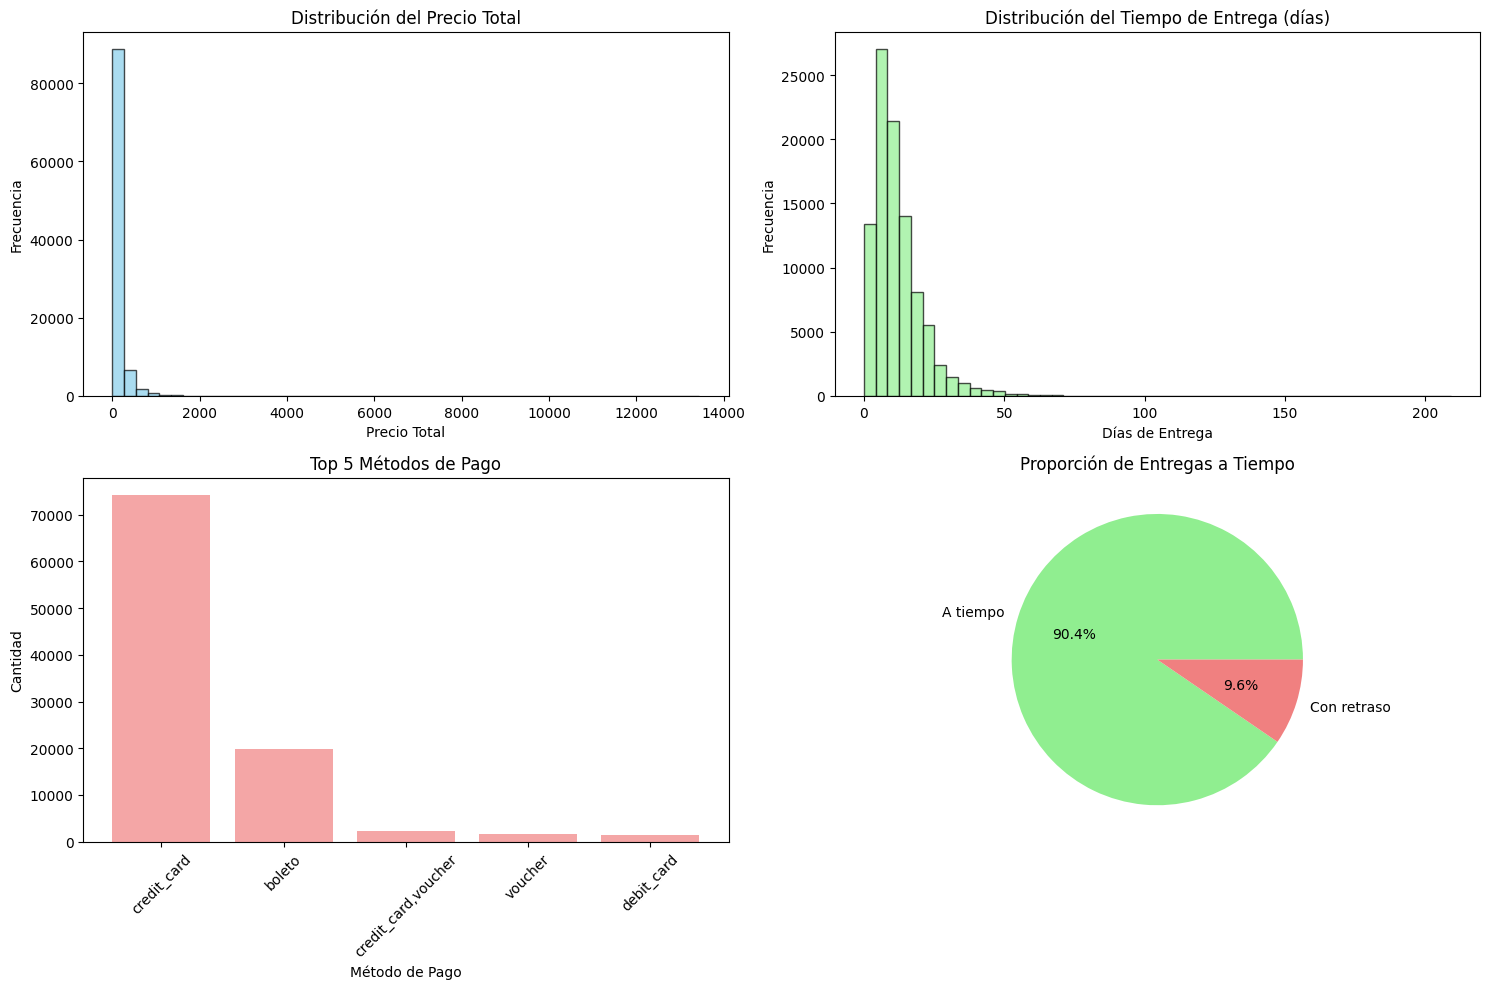


💾 Guardando dataset final...
✓ Dataset guardado como: olist_selected_features_clean.csv

RESUMEN FINAL DEL PROCESO
✅ Columnas seleccionadas: 30
✅ Registros procesados: 99,441
✅ Período cubierto: 2016-09 a 2018-10
✅ Tasa de entrega: 97.0%
✅ Tasa de cancelación: 0.6%

👀 Vista previa de los datos:


,order_id,customer_id,order_purchase_timestamp,customer_city,customer_state,payment_types,payments_count,total_items,distinct_products,distinct_sellers,...,carrier_lag_hours,delivery_delay_vs_estimate,delivered_on_time,order_month,order_week,weekday_purchase,hour_purchase,freight_ratio,is_delivered,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,sao paulo,SP,"credit_card,voucher",3.0,1.0,1.0,1.0,...,56.795833,-8.0,1,2017-10,2017-10-02/2017-10-08,0,10,0.290764,1,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,barreiras,BA,boleto,1.0,1.0,1.0,1.0,...,11.109167,-6.0,1,2018-07,2018-07-23/2018-07-29,1,20,0.191744,1,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,vianopolis,GO,credit_card,1.0,1.0,1.0,1.0,...,4.910278,-18.0,1,2018-08,2018-08-06/2018-08-12,2,8,0.120200,1,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,sao goncalo do amarante,RN,credit_card,1.0,1.0,1.0,1.0,...,89.900000,-13.0,1,2017-11,2017-11-13/2017-11-19,5,19,0.604444,1,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,santo andre,SP,credit_card,1.0,1.0,1.0,1.0,...,21.434722,-10.0,1,2018-02,2018-02-12/2018-02-18,1,21,0.438191,1,0
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,2017-07-09 21:57:05,congonhinhas,PR,credit_card,1.0,1.0,1.0,1.0,...,40.797500,-6.0,1,2017-07,2017-07-03/2017-07-09,6,21,0.184990,1,0
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,2017-04-11 12:22:08,santa rosa,RS,credit_card,1.0,1.0,1.0,1.0,...,NaN,NaN,0,2017-04,2017-04-10/2017-04-16,1,12,0.321643,0,0
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,2017-05-16 13:10:30,nilopolis,RJ,credit_card,1.0,1.0,1.0,1.0,...,140.759722,-12.0,1,2017-05,2017-05-15/2017-05-21,1,13,0.252875,1,0
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,2017-01-23 18:29:09,faxinalzinho,RS,boleto,1.0,1.0,1.0,1.0,...,35.428889,-32.0,1,2017-01,2017-01-23/2017-01-29,0,18,0.806533,1,0
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,2017-07-29 11:55:02,sorocaba,SP,"credit_card,voucher",2.0,1.0,1.0,1.0,...,295.664444,-7.0,1,2017-07,2017-07-24/2017-07-30,5,11,0.131809,1,0



🎯 ¡Proceso completado exitosamente!


In [7]:
# 2. FUNCIÓN AUXILIAR PARA MODO
def mode_or_nan(series: pd.Series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan

# 3. CONSTRUCCIÓN DE LA TABLA MASTER SIMPLIFICADA
def build_selected_features_table(save: bool = False, output_dir: Path = Path('data/interim')) -> pd.DataFrame:
    """
    Construye una tabla con las columnas seleccionadas específicamente
    """
    # Crear copias para no modificar los originales
    orders_tmp = orders.copy()
    payments_tmp = payments.copy()
    items_tmp = items.copy()
    customers_tmp = customers.copy()
    products_tmp = products.copy()
    sellers_tmp = sellers.copy()
    reviews_tmp = reviews.copy()
    translation_tmp = translation.copy()

    # Convertir fechas
    items_tmp['shipping_limit_date'] = pd.to_datetime(items_tmp['shipping_limit_date'], errors='coerce')

    # AGRUPACIÓN DE PAYMENTS
    payments_agg = (
        payments_tmp.groupby('order_id').agg(
            payment_types=pd.NamedAgg(column='payment_type', aggfunc=lambda x: ','.join(sorted(set(x)))),
            payments_count=pd.NamedAgg(column='payment_sequential', aggfunc='count')
        ).reset_index()
    )

    # AGRUPACIÓN DE ITEMS
    items_agg = (
        items_tmp.groupby('order_id').agg(
            total_items=pd.NamedAgg(column='order_item_id', aggfunc='count'),
            distinct_products=pd.NamedAgg(column='product_id', aggfunc=pd.Series.nunique),
            distinct_sellers=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique),
            total_price=pd.NamedAgg(column='price', aggfunc='sum'),
            total_freight=pd.NamedAgg(column='freight_value', aggfunc='sum'),
            shipping_limit_max=pd.NamedAgg(column='shipping_limit_date', aggfunc='max'),
            shipping_limit_min=pd.NamedAgg(column='shipping_limit_date', aggfunc='min')
        ).reset_index()
    )

    # AGRUPACIÓN DE PRODUCTOS (para categoría)
    items_products = items_tmp.merge(products_tmp, on='product_id', how='left')
    items_products = items_products.merge(translation_tmp, on='product_category_name', how='left')

    product_agg = (
        items_products.groupby('order_id').agg(
            top_category_en=pd.NamedAgg(column='product_category_name_english', aggfunc=mode_or_nan)
        ).reset_index()
    )

    # AGRUPACIÓN DE SELLERS
    items_sellers = items_tmp.merge(sellers_tmp, on='seller_id', how='left')
    seller_agg = (
        items_sellers.groupby('order_id').agg(
            seller_state_mode=pd.NamedAgg(column='seller_state', aggfunc=mode_or_nan),
            seller_city_mode=pd.NamedAgg(column='seller_city', aggfunc=mode_or_nan)
        ).reset_index()
    )

    # AGRUPACIÓN DE REVIEWS
    reviews_agg = (
        reviews_tmp.groupby('order_id').agg(
            review_count=pd.NamedAgg(column='review_id', aggfunc='count')
        ).reset_index()
    )

    # CONSTRUCCIÓN DE LA TABLA PRINCIPAL
    master = (orders_tmp
              .merge(customers_tmp, on='customer_id', how='left')
              .merge(payments_agg, on='order_id', how='left')
              .merge(items_agg, on='order_id', how='left')
              .merge(product_agg, on='order_id', how='left')
              .merge(seller_agg, on='order_id', how='left')
              .merge(reviews_agg, on='order_id', how='left'))

    # CONVERSIÓN DE FECHAS
    date_columns = [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]

    for col in date_columns:
        master[col] = pd.to_datetime(master[col], errors='coerce')

    # CÁLCULO DE FEATURES TEMPORALES
    master['delivery_time_days'] = (
        master['order_delivered_customer_date'] - master['order_purchase_timestamp']
    ).dt.days

    master['approval_lag_hours'] = (
        master['order_approved_at'] - master['order_purchase_timestamp']
    ).dt.total_seconds() / 3600

    master['carrier_lag_hours'] = (
        master['order_delivered_carrier_date'] - master['order_approved_at']
    ).dt.total_seconds() / 3600

    master['delivery_delay_vs_estimate'] = (
        master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
    ).dt.days

    master['delivered_on_time'] = (master['delivery_delay_vs_estimate'] <= 0).astype(int)

    # FEATURES TEMPORALES ADICIONALES
    master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
    master['order_week'] = master['order_purchase_timestamp'].dt.to_period('W').astype(str)
    master['weekday_purchase'] = master['order_purchase_timestamp'].dt.dayofweek
    master['hour_purchase'] = master['order_purchase_timestamp'].dt.hour

    # FEATURES DERIVADAS
    master['freight_ratio'] = master['total_freight'] / master['total_price']
    master['is_delivered'] = (master['order_status'] == 'delivered').astype(int)
    master['is_canceled'] = (master['order_status'] == 'canceled').astype(int)

    # REEMPLAZAR INFINITOS POR NaN
    master.replace([np.inf, -np.inf], np.nan, inplace=True)

    # SELECCIONAR COLUMNAS ESPECÍFICAS
    selected_columns = [
        'order_id',
        'customer_id',
        'order_purchase_timestamp',
        'customer_city',
        'customer_state',
        'payment_types',
        'payments_count',
        'total_items',
        'distinct_products',
        'distinct_sellers',
        'total_price',
        'total_freight',
        'shipping_limit_max',
        'shipping_limit_min',
        'top_category_en',
        'seller_state_mode',
        'seller_city_mode',
        'review_count',
        'delivery_time_days',
        'approval_lag_hours',
        'carrier_lag_hours',
        'delivery_delay_vs_estimate',
        'delivered_on_time',
        'order_month',
        'order_week',
        'weekday_purchase',
        'hour_purchase',
        'freight_ratio',
        'is_delivered',
        'is_canceled'
    ]

    # Filtrar solo las columnas que existen
    available_columns = [col for col in selected_columns if col in master.columns]
    final_table = master[available_columns].copy()

    # GUARDAR SI SE SOLICITA
    if save:
        output_dir = Path(output_dir)
        output_dir.mkdir(parents=True, exist_ok=True)
        file_path = output_dir / "selected_features_table.csv"
        final_table.to_csv(file_path, index=False)
        print(f"✓ Tabla guardada en: {file_path}")

    print(f"✓ Tabla final generada: {final_table.shape[0]} registros y {final_table.shape[1]} columnas")
    return final_table

# 4. EJECUTAR LA CONSTRUCCIÓN
print("\nConstruyendo tabla con features seleccionados...")
selected_features_df = build_selected_features_table(save=True)

# 5. ANÁLISIS EXPLORATORIO BÁSICO
print("\n" + "="*50)
print("ANÁLISIS EXPLORATORIO DE LA TABLA FINAL")
print("="*50)

# Información básica
print(f"📊 Dimensiones de la tabla: {selected_features_df.shape}")
print(f"📅 Rango temporal: {selected_features_df['order_month'].min()} a {selected_features_df['order_month'].max()}")

# Estadísticas descriptivas
print("\n📈 Estadísticas descriptivas de variables numéricas:")
numeric_cols = selected_features_df.select_dtypes(include=[np.number]).columns.tolist()
print(selected_features_df[numeric_cols].describe())

# Valores nulos
print("\n🔍 Valores nulos por columna:")
null_summary = selected_features_df.isnull().sum()
null_summary = null_summary[null_summary > 0]
if len(null_summary) > 0:
    for col, null_count in null_summary.items():
        null_pct = (null_count / len(selected_features_df)) * 100
        print(f"  {col}: {null_count} nulos ({null_pct:.2f}%)")
else:
    print("  ✓ No hay valores nulos")

# Distribución de estados clave
print("\n🏙️ Top 5 ciudades de clientes:")
print(selected_features_df['customer_city'].value_counts().head(5))

print("\n🏢 Top 5 estados de vendedores:")
print(selected_features_df['seller_state_mode'].value_counts().head(5))

print("\n📦 Distribución de estados de orden:")
print(f"  Entregados: {selected_features_df['is_delivered'].sum()} ({selected_features_df['is_delivered'].mean()*100:.1f}%)")
print(f"  Cancelados: {selected_features_df['is_canceled'].sum()} ({selected_features_df['is_canceled'].mean()*100:.1f}%)")

# 6. VISUALIZACIONES BÁSICAS
print("\n📊 Generando visualizaciones...")

# Configurar el estilo de las gráficas
plt.style.use('default')
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Distribución de precios
axes[0,0].hist(selected_features_df['total_price'].dropna(), bins=50, alpha=0.7, color='skyblue', edgecolor='black')
axes[0,0].set_title('Distribución del Precio Total')
axes[0,0].set_xlabel('Precio Total')
axes[0,0].set_ylabel('Frecuencia')

# Distribución de tiempo de entrega
axes[0,1].hist(selected_features_df['delivery_time_days'].dropna(), bins=50, alpha=0.7, color='lightgreen', edgecolor='black')
axes[0,1].set_title('Distribución del Tiempo de Entrega (días)')
axes[0,1].set_xlabel('Días de Entrega')
axes[0,1].set_ylabel('Frecuencia')

# Distribución de métodos de pago
payment_counts = selected_features_df['payment_types'].value_counts().head(5)
axes[1,0].bar(payment_counts.index, payment_counts.values, color='lightcoral', alpha=0.7)
axes[1,0].set_title('Top 5 Métodos de Pago')
axes[1,0].set_xlabel('Método de Pago')
axes[1,0].set_ylabel('Cantidad')
axes[1,0].tick_params(axis='x', rotation=45)

# Entregas a tiempo vs retrasadas
on_time_counts = selected_features_df['delivered_on_time'].value_counts()
axes[1,1].pie(on_time_counts.values, labels=['A tiempo', 'Con retraso'], autopct='%1.1f%%',
              colors=['lightgreen', 'lightcoral'])
axes[1,1].set_title('Proporción de Entregas a Tiempo')

plt.tight_layout()
plt.show()

# 7. GUARDAR DATASET FINAL
print("\n💾 Guardando dataset final...")
selected_features_df.to_csv('olist_selected_features_clean.csv', index=False)
print("✓ Dataset guardado como: olist_selected_features_clean.csv")

# 8. RESUMEN FINAL
print("\n" + "="*50)
print("RESUMEN FINAL DEL PROCESO")
print("="*50)
print(f"✅ Columnas seleccionadas: {len(selected_features_df.columns)}")
print(f"✅ Registros procesados: {len(selected_features_df):,}")
print(f"✅ Período cubierto: {selected_features_df['order_month'].min()} a {selected_features_df['order_month'].max()}")
print(f"✅ Tasa de entrega: {selected_features_df['is_delivered'].mean()*100:.1f}%")
print(f"✅ Tasa de cancelación: {selected_features_df['is_canceled'].mean()*100:.1f}%")

# Mostrar primeras filas
print("\n👀 Vista previa de los datos:")
display(selected_features_df.head(10))

print("\n🎯 ¡Proceso completado exitosamente!")

In [8]:
from google.colab import files

# Asegurarse de que el archivo existe
import os
if os.path.exists('olist_selected_features_clean.csv'):
    files.download('olist_selected_features_clean.csv')
    print("✅ Archivo descargado exitosamente!")
else:
    print("❌ El archivo no existe. Ejecuta primero el código de limpieza.")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Archivo descargado exitosamente!


MATRIZ DE CORRELACION


🔍 Analizando matriz de correlación...
✅ Dataset cargado: 99441 filas, 30 columnas

📊 Preparando datos para análisis de correlación...
📈 Columnas numéricas para correlación: 14

🧮 Calculando matriz de correlación...


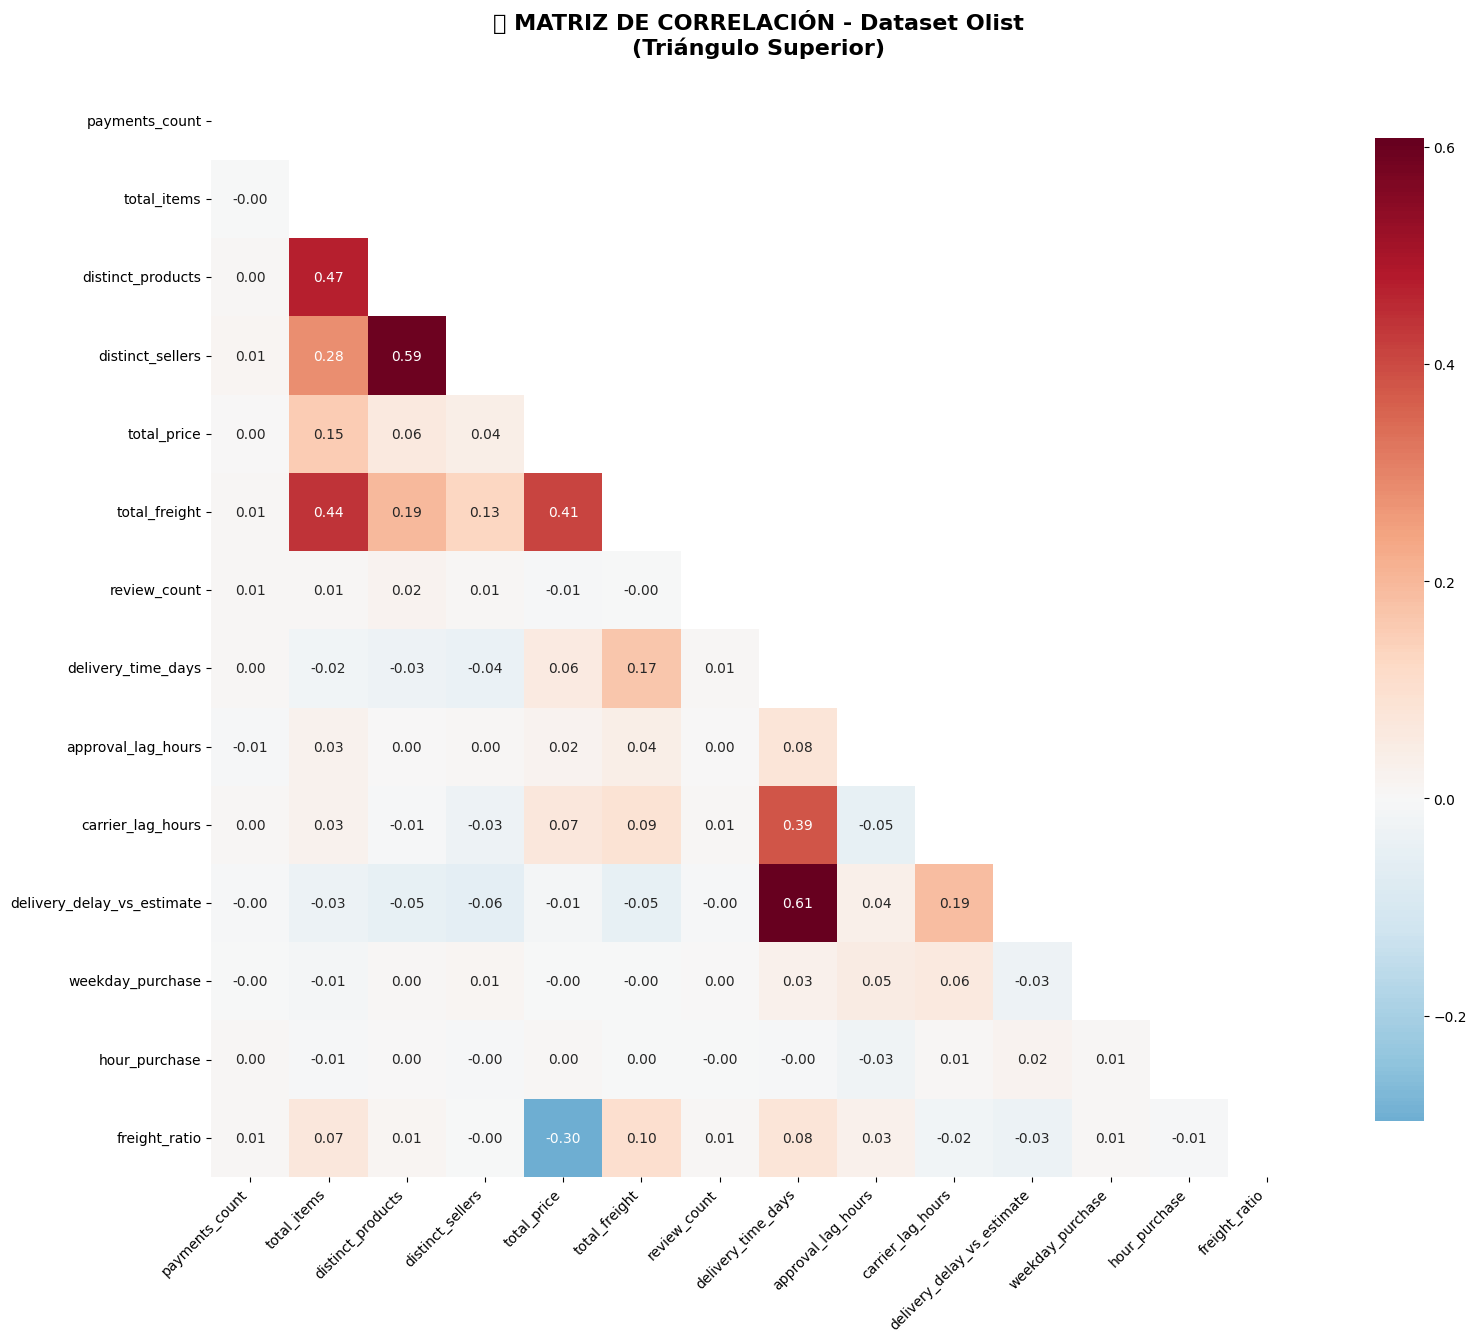

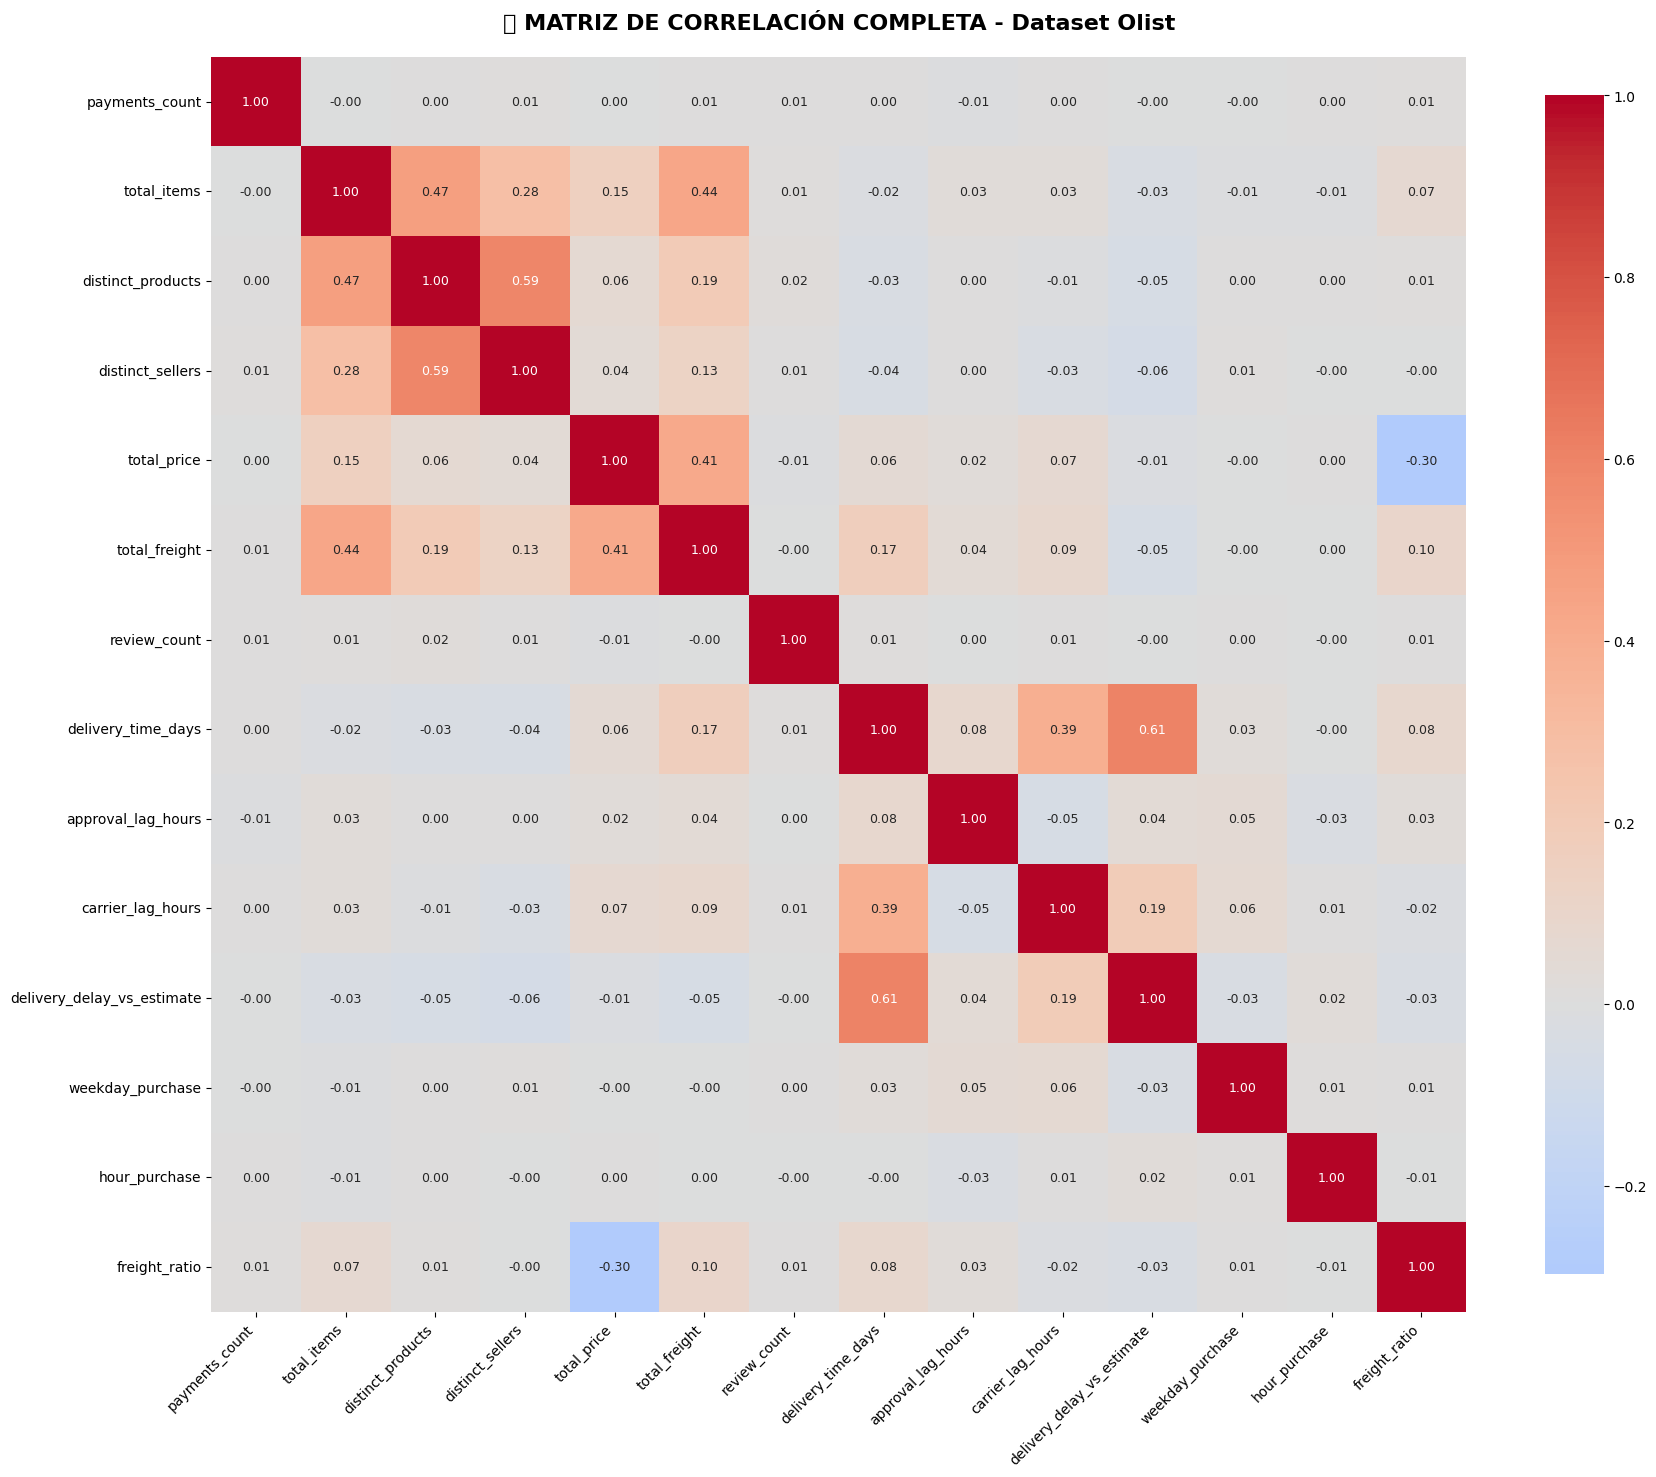


🏆 TOP 20 CORRELACIONES MÁS FUERTES:


,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,delivery_time_days,delivery_delay_vs_estimate,0.607716,Positiva,Moderada
1,distinct_sellers,distinct_products,0.592784,Positiva,Moderada
2,total_items,distinct_products,0.470977,Positiva,Moderada
3,total_freight,total_items,0.436941,Positiva,Moderada
4,total_price,total_freight,0.412786,Positiva,Moderada
5,carrier_lag_hours,delivery_time_days,0.385048,Positiva,Moderada
6,total_price,freight_ratio,-0.296493,Negativa,Débil
7,distinct_sellers,total_items,0.282200,Positiva,Débil
8,total_freight,distinct_products,0.194978,Positiva,Débil
9,delivery_delay_vs_estimate,carrier_lag_hours,0.189998,Positiva,Débil



🎯 CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO:

📋 Correlaciones con 'delivery_time_days':
   delivery_delay_vs_estimate :   0.608 (🟡 MODERADA)
   carrier_lag_hours         :   0.385 (🟡 MODERADA)
   total_freight             :   0.167 (🟢 DÉBIL)
   approval_lag_hours        :   0.080 (🟢 DÉBIL)
   freight_ratio             :   0.080 (🟢 DÉBIL)

📋 Correlaciones con 'total_price':
   total_freight             :   0.413 (🟡 MODERADA)
   freight_ratio             :  -0.296 (🟢 DÉBIL)
   total_items               :   0.153 (🟢 DÉBIL)
   carrier_lag_hours         :   0.070 (🟢 DÉBIL)
   distinct_products         :   0.061 (🟢 DÉBIL)

📋 Correlaciones con 'freight_ratio':
   total_price               :  -0.296 (🟢 DÉBIL)
   total_freight             :   0.103 (🟢 DÉBIL)
   delivery_time_days        :   0.080 (🟢 DÉBIL)
   total_items               :   0.068 (🟢 DÉBIL)
   delivery_delay_vs_estimate :  -0.032 (🟢 DÉBIL)


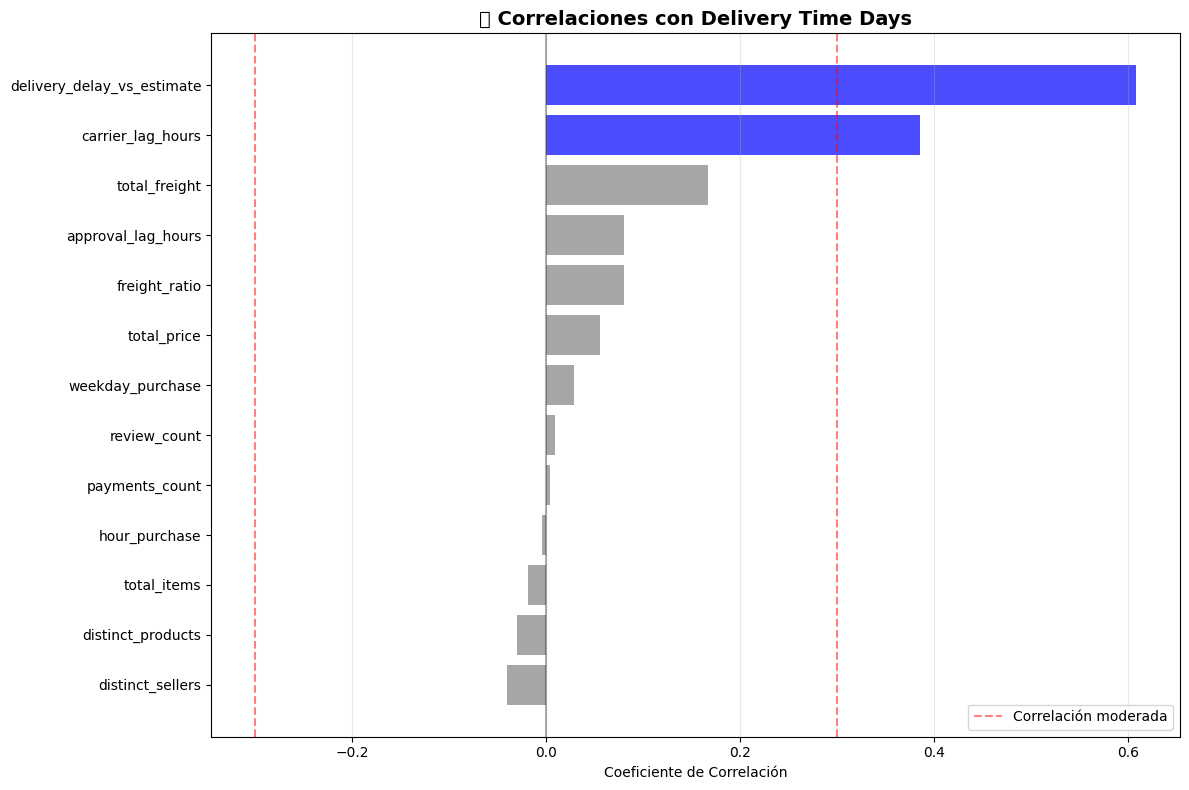

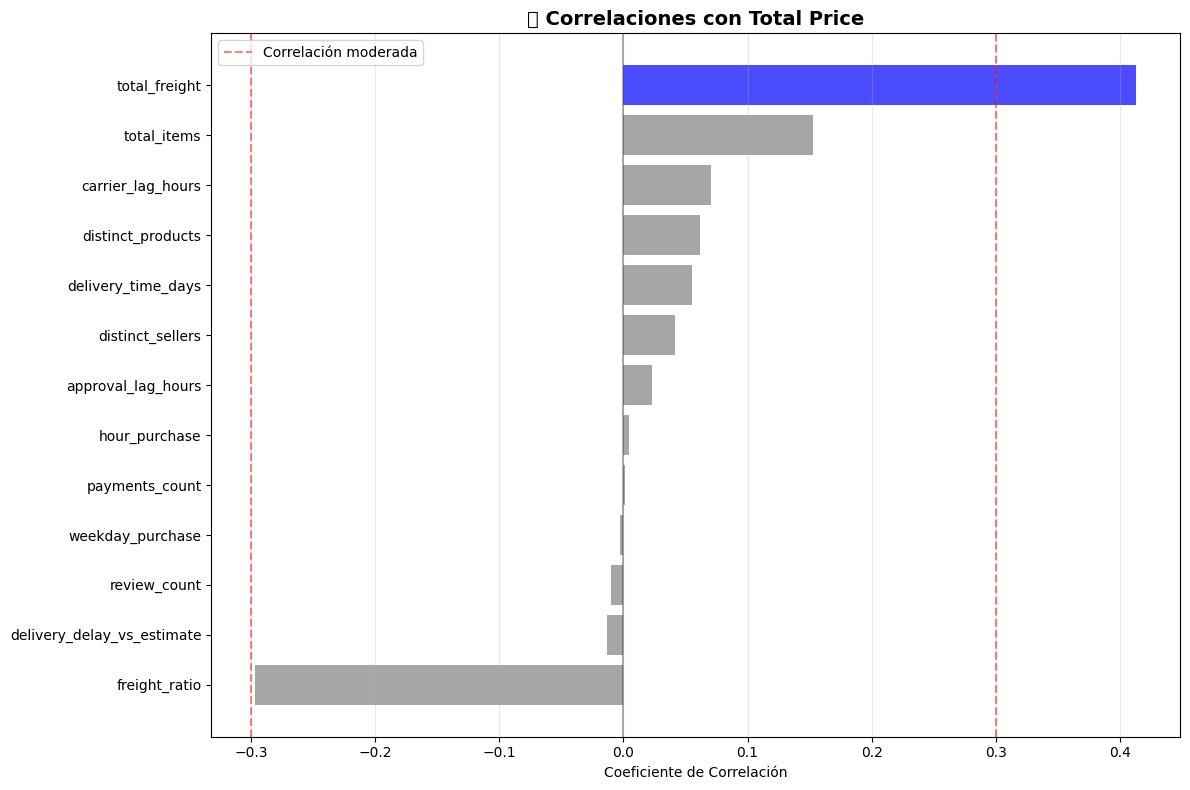


⚠️  ANÁLISIS DE MULTICOLINEALIDAD:
✅ No se detectaron pares con correlación muy alta (>0.8)

📊 RESUMEN ESTADÍSTICO DE CORRELACIONES:
   Total de pares analizados: 91
   Correlación promedio (abs): 0.06663875466273522
   Correlación máxima: 0.6077160203878645
   Correlación mínima: -0.29649334671525174
   Pares con correlación > 0.7: 0
   Pares con correlación > 0.5: 2
   Pares con correlación > 0.3: 6

💾 Matriz de correlación guardada como: 'matriz_correlacion_olist.csv'


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Matriz de correlación descargada

🎉 ANÁLISIS DE CORRELACIÓN COMPLETADO


In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Configuración de estilo
plt.style.use('default')
sns.set_palette("husl")
print("🔍 Analizando matriz de correlación...")

# Cargar el dataset
try:
    df = pd.read_csv('olist_selected_features_clean.csv')
    print(f"✅ Dataset cargado: {df.shape[0]} filas, {df.shape[1]} columnas")
except:
    print("❌ No se pudo cargar el archivo. Asegúrate de que existe 'olist_selected_features_clean.csv'")
    # Si no existe, usar los datos de la sesión actual
    if 'selected_features_df' in locals():
        df = selected_features_df
        print("✅ Usando dataset de la sesión actual")
    else:
        raise Exception("No se encontró el dataset. Ejecuta primero el código de limpieza.")

# 1. PREPARACIÓN DE DATOS PARA CORRELACIÓN
print("\n📊 Preparando datos para análisis de correlación...")

# Seleccionar solo columnas numéricas
numeric_df = df.select_dtypes(include=[np.number])

# Excluir columnas binarias si se desea (opcional)
binary_columns = ['is_delivered', 'is_canceled', 'delivered_on_time']
numeric_df = numeric_df[[col for col in numeric_df.columns if col not in binary_columns or df[col].nunique() > 2]]

print(f"📈 Columnas numéricas para correlación: {len(numeric_df.columns)}")

# 2. MATRIZ DE CORRELACIÓN BÁSICA
print("\n🧮 Calculando matriz de correlación...")
correlation_matrix = numeric_df.corr()

# 3. VISUALIZACIÓN 1: MATRIZ DE CORRELACIÓN CON HEATMAP
plt.figure(figsize=(16, 14))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Máscara para triángulo superior

heatmap = sns.heatmap(correlation_matrix,
                      mask=mask,
                      annot=True,
                      fmt=".2f",
                      cmap="RdBu_r",
                      center=0,
                      square=True,
                      cbar_kws={"shrink": .8},
                      annot_kws={"size": 10})

plt.title('🔗 MATRIZ DE CORRELACIÓN - Dataset Olist\n(Triángulo Superior)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 4. VISUALIZACIÓN 2: MATRIZ COMPLETA
plt.figure(figsize=(18, 16))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 9})

plt.title('🔗 MATRIZ DE CORRELACIÓN COMPLETA - Dataset Olist',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 5. CORRELACIONES MÁS FUERTES (TOP 20)
print("\n🏆 TOP 20 CORRELACIONES MÁS FUERTES:")

# Crear DataFrame de correlaciones
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False, key=abs)

# Filtrar autocorrelaciones y duplicados
corr_pairs = corr_pairs[corr_pairs < 0.999]  # Remover autocorrelaciones perfectas

# Crear tabla ordenada
top_correlations = []
for idx in range(0, min(40, len(corr_pairs)), 2):  # Tomar pares únicos
    if idx < len(corr_pairs):
        pair = corr_pairs.index[idx]
        value = corr_pairs.iloc[idx]
        if pair[0] != pair[1]:  # Evitar duplicados
            top_correlations.append({
                'Variable 1': pair[0],
                'Variable 2': pair[1],
                'Correlación': value,
                'Tipo': 'Positiva' if value > 0 else 'Negativa',
                'Fuerza': 'Fuerte' if abs(value) > 0.7 else
                         'Moderada' if abs(value) > 0.3 else 'Débil'
            })

top_corr_df = pd.DataFrame(top_correlations).head(20)
display(top_corr_df)

# 6. CORRELACIONES CON VARIABLES CLAVE
print("\n🎯 CORRELACIONES CON VARIABLES CLAVE DE NEGOCIO:")

key_variables = ['delivery_time_days', 'total_price', 'delivered_on_time',
                 'is_delivered', 'is_canceled', 'freight_ratio']

for key_var in key_variables:
    if key_var in correlation_matrix.columns:
        print(f"\n📋 Correlaciones con '{key_var}':")
        corrs_with_key = correlation_matrix[key_var].sort_values(ascending=False, key=abs)
        corrs_with_key = corrs_with_key[corrs_with_key.index != key_var]  # Excluir autocorrelación
        for var, corr in corrs_with_key.head(5).items():
            strength = "🔴 FUERTE" if abs(corr) > 0.7 else "🟡 MODERADA" if abs(corr) > 0.3 else "🟢 DÉBIL"
            print(f"   {var:25} : {corr:7.3f} ({strength})")

# 7. VISUALIZACIÓN 3: CORRELACIONES CON DELIVERY TIME (si existe)
if 'delivery_time_days' in correlation_matrix.columns:
    plt.figure(figsize=(12, 8))
    delivery_corrs = correlation_matrix['delivery_time_days'].drop('delivery_time_days')
    delivery_corrs = delivery_corrs.sort_values(ascending=True)

    colors = ['red' if x < -0.3 else 'blue' if x > 0.3 else 'gray' for x in delivery_corrs]

    plt.barh(delivery_corrs.index, delivery_corrs.values, color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Correlación moderada')
    plt.axvline(x=-0.3, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Coeficiente de Correlación')
    plt.title('📦 Correlaciones con Delivery Time Days', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 8. VISUALIZACIÓN 4: CORRELACIONES CON TOTAL PRICE (si existe)
if 'total_price' in correlation_matrix.columns:
    plt.figure(figsize=(12, 8))
    price_corrs = correlation_matrix['total_price'].drop('total_price')
    price_corrs = price_corrs.sort_values(ascending=True)

    colors = ['red' if x < -0.3 else 'blue' if x > 0.3 else 'gray' for x in price_corrs]

    plt.barh(price_corrs.index, price_corrs.values, color=colors, alpha=0.7)
    plt.axvline(x=0, color='black', linestyle='-', alpha=0.3)
    plt.axvline(x=0.3, color='red', linestyle='--', alpha=0.5, label='Correlación moderada')
    plt.axvline(x=-0.3, color='red', linestyle='--', alpha=0.5)
    plt.xlabel('Coeficiente de Correlación')
    plt.title('💰 Correlaciones con Total Price', fontsize=14, fontweight='bold')
    plt.grid(axis='x', alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()

# 9. ANÁLISIS DE MULTICOLINEALIDAD
print("\n⚠️  ANÁLISIS DE MULTICOLINEALIDAD:")
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.8:  # Umbral para multicolinealidad alta
            high_corr_pairs.append({
                'Variable 1': correlation_matrix.columns[i],
                'Variable 2': correlation_matrix.columns[j],
                'Correlación': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs)
    print("🚨 Pares con alta correlación (posible multicolinealidad):")
    display(high_corr_df)
else:
    print("✅ No se detectaron pares con correlación muy alta (>0.8)")

# 10. RESUMEN ESTADÍSTICO DE CORRELACIONES
print("\n📊 RESUMEN ESTADÍSTICO DE CORRELACIONES:")
corr_values = correlation_matrix.values[np.triu_indices_from(correlation_matrix.values, k=1)]
summary_stats = {
    'Total de pares analizados': len(corr_values),
    'Correlación promedio (abs)': np.mean(np.abs(corr_values)),
    'Correlación máxima': np.max(corr_values),
    'Correlación mínima': np.min(corr_values),
    'Pares con correlación > 0.7': np.sum(np.abs(corr_values) > 0.7),
    'Pares con correlación > 0.5': np.sum(np.abs(corr_values) > 0.5),
    'Pares con correlación > 0.3': np.sum(np.abs(corr_values) > 0.3),
}

for stat, value in summary_stats.items():
    print(f"   {stat}: {value}")

# 11. GUARDAR MATRIZ DE CORRELACIÓN
correlation_matrix.to_csv('matriz_correlacion_olist.csv')
print(f"\n💾 Matriz de correlación guardada como: 'matriz_correlacion_olist.csv'")

# Opcional: Descargar la matriz
try:
    files.download('matriz_correlacion_olist.csv')
    print("✅ Matriz de correlación descargada")
except:
    print("ℹ️  La matriz se guardó localmente")

print("\n🎉 ANÁLISIS DE CORRELACIÓN COMPLETADO")

2.Incorporando OTRAS las columnas TALVEZ

🚀 INICIANDO PROCESO COMPLETO DE LIMPIEZA Y ANÁLISIS

📥 Cargando datasets...
✅ Todos los datasets cargados exitosamente

CONSTRUYENDO DATASET CON FEATURES PERSONALIZADOS

🔧 Construyendo tabla con features personalizados...
⏰ Calculando features temporales...
💰 Calculando features de negocio...
🧹 Aplicando limpieza final...
💾 Tabla guardada en: data/interim/custom_features_dataset.csv
✅ Tabla final generada: 99441 registros y 39 columnas

ANÁLISIS EXPLORATORIO DEL DATASET
📊 Dimensiones del dataset: (99441, 39)
📅 Rango temporal: 2016-09 a 2018-10

📈 Resumen de variables numéricas:


,payment_total,payment_installments_max,payments_count,total_items,distinct_products,distinct_sellers,total_price,max_price,min_price,total_freight,review_count,review_latest_score,delivery_time_days,approval_lag_hours,carrier_lag_hours,delivery_delay_vs_estimate,delivered_on_time,weekday_purchase,hour_purchase,avg_item_value,freight_ratio,contribution_margin_proxy,is_delivered,is_canceled
count,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000,99441.000000
mean,160.989707,2.930512,1.044710,1.140626,1.037801,1.013516,131.444374,126.267499,124.930805,22.779500,1.005541,4.093774,12.031647,10.402882,66.893006,-11.880552,0.904466,2.755735,14.770829,125.553587,0.307734,114.545119,0.970203,0.006285
std,221.950211,2.715673,0.381164,0.536495,0.225597,0.121826,155.415917,190.983982,190.183012,21.572104,0.074772,1.344488,9.415006,26.020182,84.471945,10.030901,0.293953,1.966495,5.326800,190.284680,0.313620,201.925156,0.170027,0.079030
min,0.000000,0.000000,1.000000,1.000000,1.000000,1.000000,0.850000,0.850000,0.850000,0.000000,1.000000,1.000000,0.000000,0.000000,-4109.256111,-147.000000,0.000000,0.000000,0.000000,0.850000,0.000000,-744.960000,0.000000,0.000000
25%,62.010000,1.000000,1.000000,1.000000,1.000000,1.000000,45.990000,42.900000,40.900000,13.900000,1.000000,4.000000,6.000000,0.215278,21.289444,-17.000000,1.000000,1.000000,11.000000,42.490000,0.132212,29.020000,1.000000,0.000000
50%,105.290000,2.000000,1.000000,1.000000,1.000000,1.000000,86.900000,79.900000,79.000000,17.170000,1.000000,5.000000,10.000000,0.343333,43.641528,-12.000000,1.000000,3.000000,15.000000,79.000000,0.224374,65.480000,1.000000,0.000000
75%,176.970000,4.000000,1.000000,1.000000,1.000000,1.000000,149.900000,139.900000,139.000000,23.920000,1.000000,5.000000,15.000000,14.537778,84.595278,-7.000000,1.000000,4.000000,19.000000,139.770000,0.378446,126.140000,1.000000,0.000000
max,13664.080000,24.000000,29.000000,21.000000,8.000000,5.000000,998.900000,6735.000000,6735.000000,1794.960000,3.000000,5.000000,209.000000,4509.180556,3018.301667,188.000000,1.000000,6.000000,23.000000,6735.000000,21.447059,13215.920000,1.000000,1.000000



🔍 Valores nulos por columna:
  order_delivered_carrier_date: 1783 nulos (1.79%)
  order_delivered_customer_date: 2965 nulos (2.98%)
  shipping_limit_max: 775 nulos (0.78%)
  shipping_limit_min: 775 nulos (0.78%)

GENERANDO Y DESCARGANDO DATASET LIMPIO
✅ Dataset limpio guardado como: olist_custom_features_clean.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Dataset descargado exitosamente!

GENERANDO MATRIZ DE CORRELACIÓN
📈 Analizando correlación entre 21 variables numéricas...


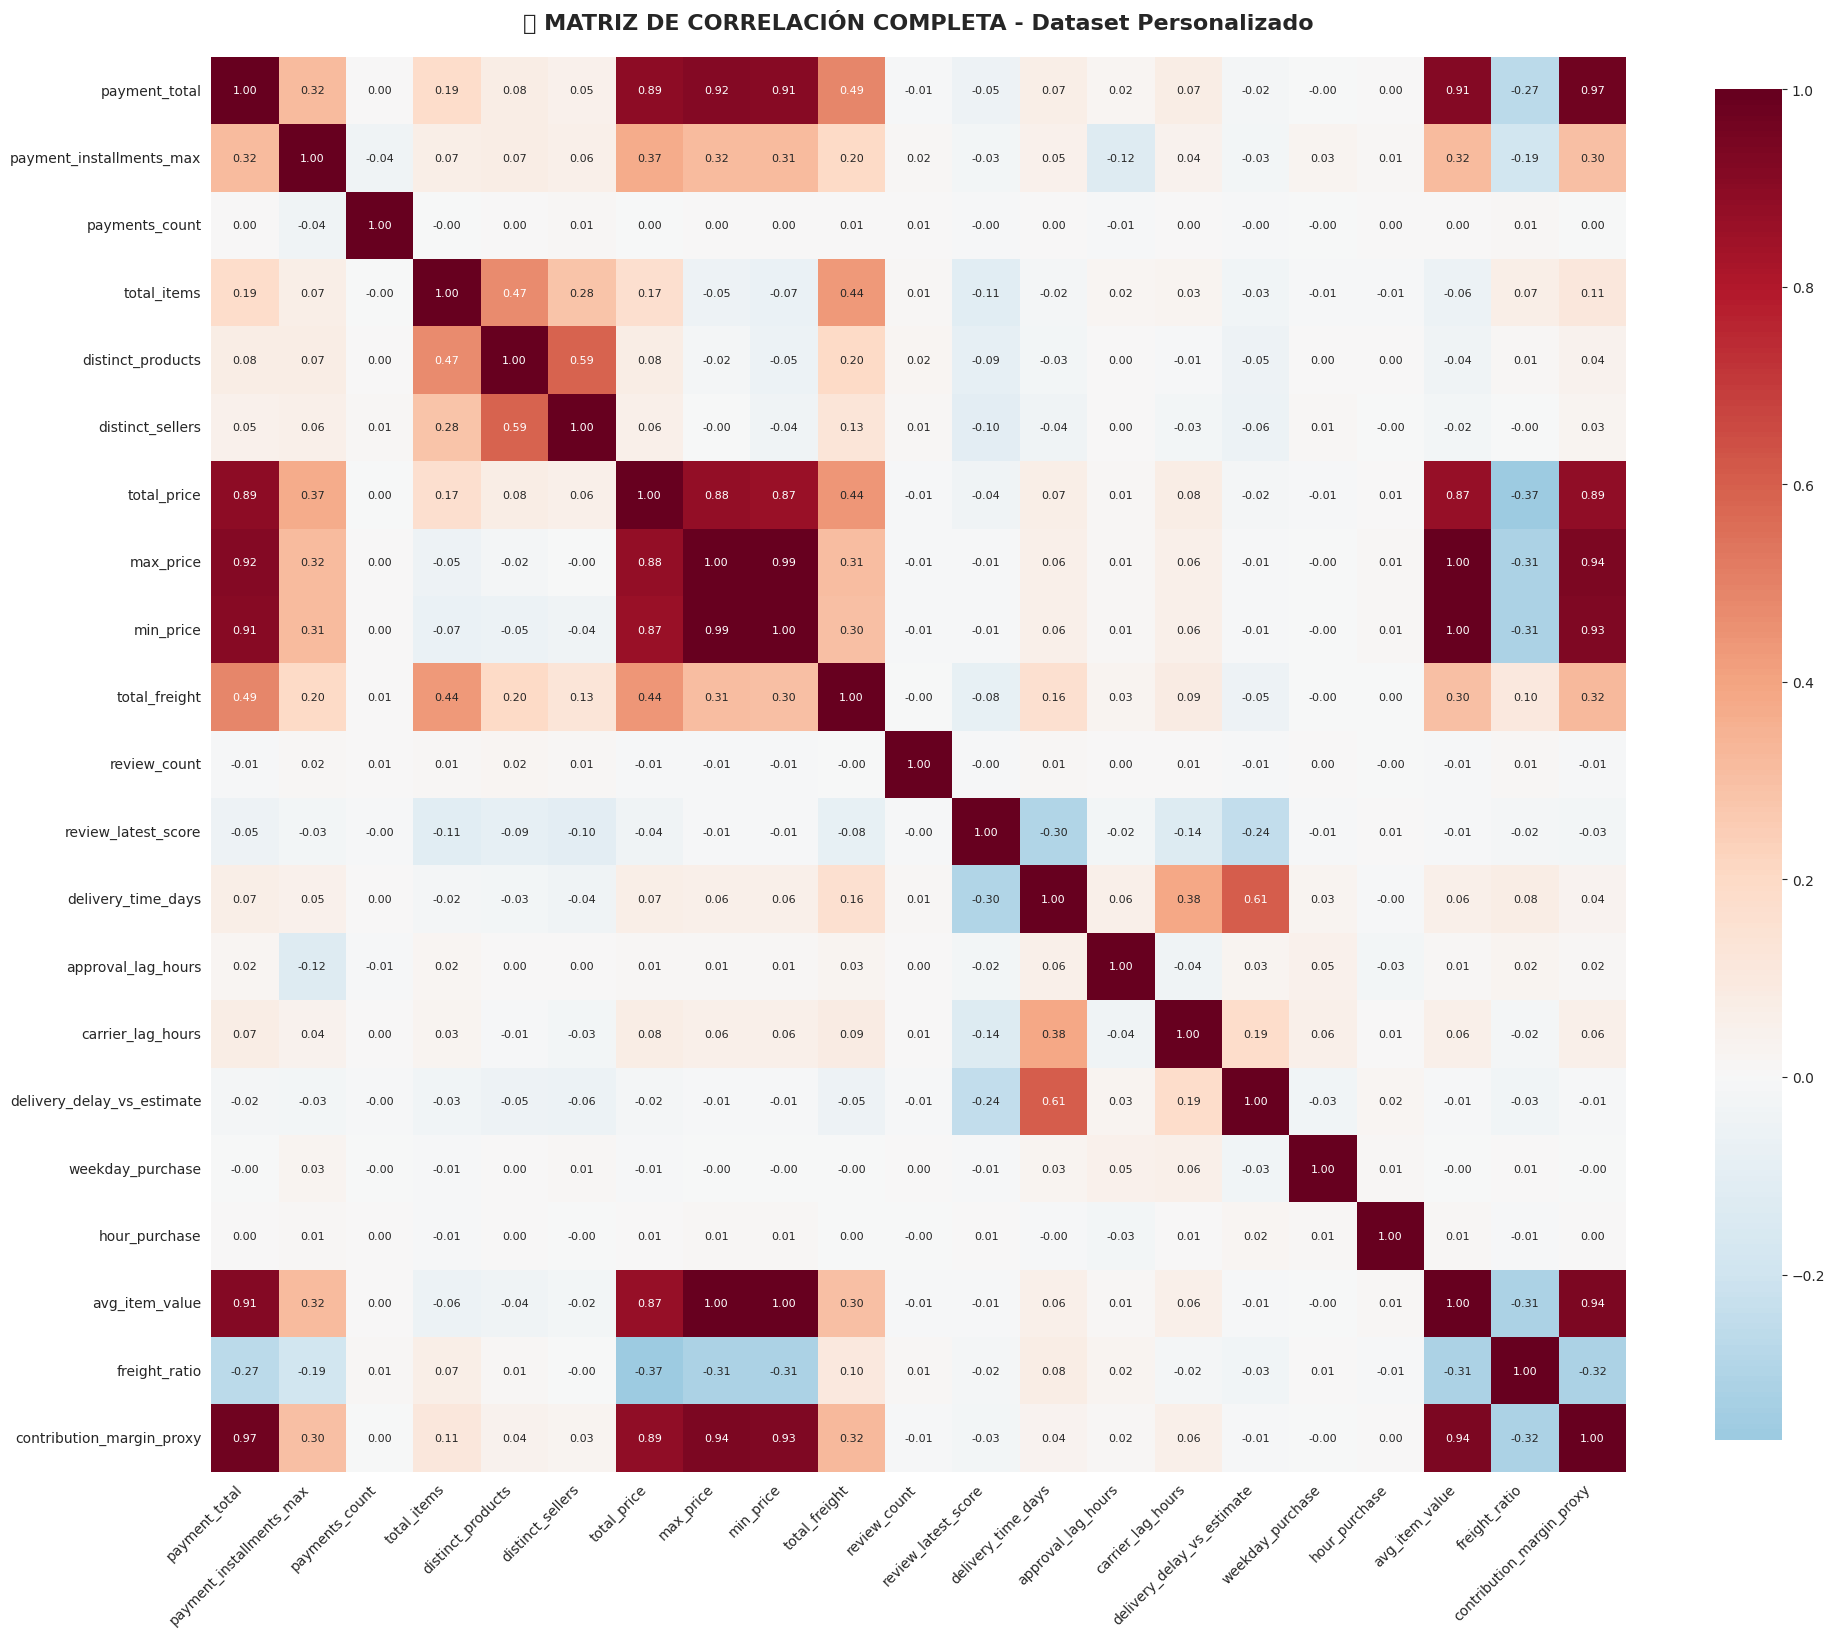

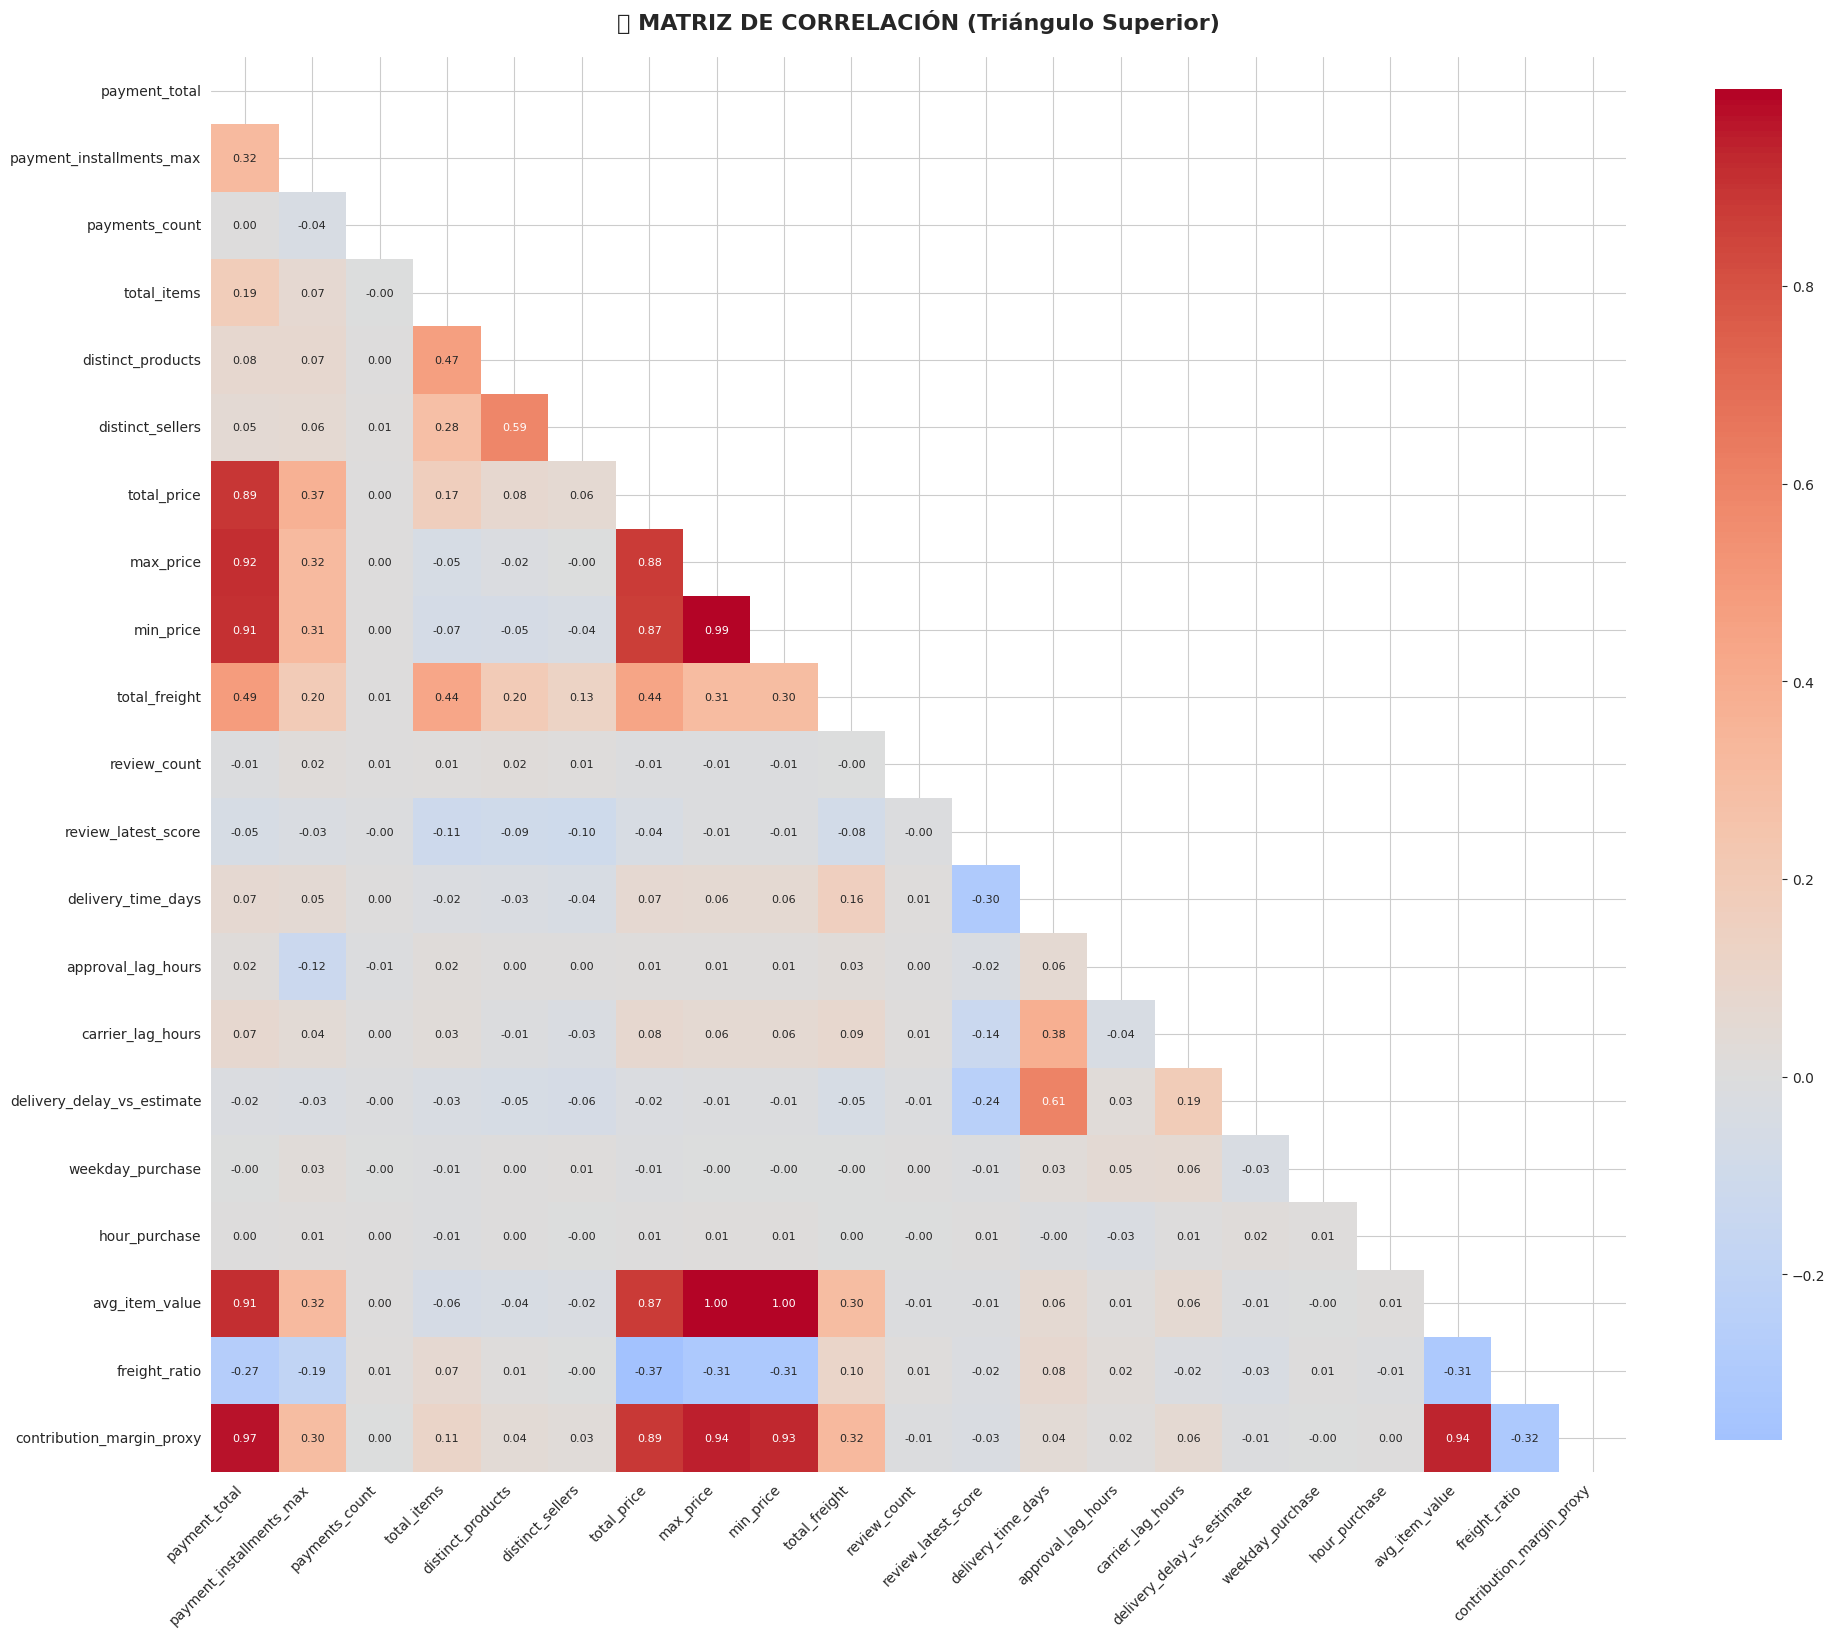


🏆 TOP 15 CORRELACIONES MÁS FUERTES:


,Variable 1,Variable 2,Correlación,Tipo,Fuerza
0,min_price,avg_item_value,0.998938,Positiva,Fuerte
1,avg_item_value,max_price,0.998119,Positiva,Fuerte
2,max_price,min_price,0.994596,Positiva,Fuerte
3,payment_total,contribution_margin_proxy,0.971581,Positiva,Fuerte
4,contribution_margin_proxy,max_price,0.941211,Positiva,Fuerte
5,avg_item_value,contribution_margin_proxy,0.937709,Positiva,Fuerte
6,min_price,contribution_margin_proxy,0.932982,Positiva,Fuerte
7,payment_total,max_price,0.915268,Positiva,Fuerte
8,avg_item_value,payment_total,0.910898,Positiva,Fuerte
9,min_price,payment_total,0.905500,Positiva,Fuerte



💾 Guardando matriz de correlación...


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

✅ Matriz de correlación guardada y descargada como: matriz_correlacion_custom.csv

🎉 PROCESO COMPLETADO EXITOSAMENTE
📁 ARCHIVOS GENERADOS:
   1. olist_custom_features_clean.csv - Dataset limpio con features personalizados
   2. matriz_correlacion_custom.csv - Matriz de correlación completa

📊 RESUMEN DEL DATASET:
   • Registros: 99,441
   • Columnas: 39
   • Período: 2016-09 a 2018-10
   • Entregas exitosas: 96,478 (97.0%)
   • Cancelaciones: 625 (0.6%)
   • Entregas a tiempo: 89,941 (90.4%)

💰 MÉTRICAS FINANCIERAS:
   • Precio promedio: R$ 131.44
   • Margen promedio: R$ 114.55
   • Ratio flete promedio: 0.31

📦 MÉTRICAS DE OPERACIONES:
   • Tiempo entrega promedio: 12.0 días
   • Lag aprobación promedio: 10.4 horas
   • Items por orden: 1.1

👀 VISTA PREVIA DEL DATASET (primeras 5 filas):


,order_id,customer_id,order_purchase_timestamp,order_delivered_carrier_date,order_delivered_customer_date,customer_city,customer_state,payment_total,payment_installments_max,payment_types,payments_count,total_items,distinct_products,distinct_sellers,total_price,max_price,min_price,total_freight,shipping_limit_max,shipping_limit_min,top_category_en,seller_state_mode,seller_city_mode,review_count,review_latest_score,delivery_time_days,approval_lag_hours,carrier_lag_hours,delivery_delay_vs_estimate,delivered_on_time,order_month,order_week,weekday_purchase,hour_purchase,avg_item_value,freight_ratio,contribution_margin_proxy,is_delivered,is_canceled
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,2017-10-02 10:56:33,2017-10-04 19:55:00,2017-10-10 21:25:13,sao paulo,SP,38.71,1.0,"credit_card,voucher",3.0,1.0,1.0,1.0,29.99,29.99,29.99,8.72,2017-10-06 11:07:15,2017-10-06 11:07:15,housewares,SP,maua,1.0,4.0,8.0,0.178333,56.795833,-8.0,1,2017-10,2017-10-02/2017-10-08,0,10,29.99,0.290764,21.27,1,0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,2018-07-24 20:41:37,2018-07-26 14:31:00,2018-08-07 15:27:45,barreiras,BA,141.46,1.0,boleto,1.0,1.0,1.0,1.0,118.70,118.70,118.70,22.76,2018-07-30 03:24:27,2018-07-30 03:24:27,perfumery,SP,belo horizonte,1.0,4.0,13.0,30.713889,11.109167,-6.0,1,2018-07,2018-07-23/2018-07-29,1,20,118.70,0.191744,95.94,1,0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,2018-08-08 08:38:49,2018-08-08 13:50:00,2018-08-17 18:06:29,vianopolis,GO,179.12,3.0,credit_card,1.0,1.0,1.0,1.0,159.90,159.90,159.90,19.22,2018-08-13 08:55:23,2018-08-13 08:55:23,auto,SP,guariba,1.0,5.0,9.0,0.276111,4.910278,-18.0,1,2018-08,2018-08-06/2018-08-12,2,8,159.90,0.120200,140.68,1,0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,2017-11-18 19:28:06,2017-11-22 13:39:59,2017-12-02 00:28:42,sao goncalo do amarante,RN,72.20,1.0,credit_card,1.0,1.0,1.0,1.0,45.00,45.00,45.00,27.20,2017-11-23 19:45:59,2017-11-23 19:45:59,pet_shop,MG,belo horizonte,1.0,5.0,13.0,0.298056,89.900000,-13.0,1,2017-11,2017-11-13/2017-11-19,5,19,45.00,0.604444,17.80,1,0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,2018-02-13 21:18:39,2018-02-14 19:46:34,2018-02-16 18:17:02,santo andre,SP,28.62,1.0,credit_card,1.0,1.0,1.0,1.0,19.90,19.90,19.90,8.72,2018-02-19 20:31:37,2018-02-19 20:31:37,stationery,SP,mogi das cruzes,1.0,5.0,2.0,1.030556,21.434722,-10.0,1,2018-02,2018-02-12/2018-02-18,1,21,19.90,0.438191,11.18,1,0



✅ ¡Todos los archivos han sido generados y descargados exitosamente!


In [11]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from google.colab import files
import warnings
warnings.filterwarnings('ignore')

# Configuración inicial
pd.set_option('display.max_columns', None)
sns.set_style("whitegrid")
print("🚀 INICIANDO PROCESO COMPLETO DE LIMPIEZA Y ANÁLISIS")

# 1. CARGAR DATOS
print("\n📥 Cargando datasets...")
customers = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_customers_dataset.csv")
items =  pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_items_dataset.csv")
payments =  pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_payments_dataset.csv")
reviews = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_order_reviews_dataset.csv")
orders = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_orders_dataset.csv")
products = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_products_dataset.csv")
sellers = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/olist_sellers_dataset.csv")
translation = pd.read_csv("https://raw.githubusercontent.com/paukiss/MIADAS13/refs/heads/main/data/dataset/product_category_name_translation.csv")


print("✅ Todos los datasets cargados exitosamente")

# 2. FUNCIONES AUXILIARES
def mode_or_nan(series: pd.Series):
    mode_vals = series.mode(dropna=True)
    return mode_vals.iloc[0] if not mode_vals.empty else np.nan

def mean_length(series: pd.Series):
    non_null = series.dropna().astype(str)
    lengths = non_null.map(len)
    return lengths.mean() if not lengths.empty else np.nan

# 3. CONSTRUCCIÓN DE LA TABLA MASTER CON FEATURES SELECCIONADOS
def build_custom_features_table(save: bool = False) -> pd.DataFrame:
    """
    Construye una tabla con las columnas específicamente seleccionadas
    """
    print("\n🔧 Construyendo tabla con features personalizados...")

    # Crear copias para no modificar los originales
    orders_tmp = orders.copy()
    payments_tmp = payments.copy()
    items_tmp = items.copy()
    customers_tmp = customers.copy()
    products_tmp = products.copy()
    sellers_tmp = sellers.copy()
    reviews_tmp = reviews.copy()
    translation_tmp = translation.copy()

    # Convertir fechas
    items_tmp['shipping_limit_date'] = pd.to_datetime(items_tmp['shipping_limit_date'], errors='coerce')
    reviews_tmp['review_creation_date'] = pd.to_datetime(reviews_tmp['review_creation_date'], errors='coerce')
    reviews_tmp['review_answer_timestamp'] = pd.to_datetime(reviews_tmp.get('review_answer_timestamp'), errors='coerce')

    # AGRUPACIÓN DE PAYMENTS
    payments_agg = (
        payments_tmp.groupby('order_id').agg(
            payment_total=pd.NamedAgg(column='payment_value', aggfunc='sum'),
            payment_installments_max=pd.NamedAgg(column='payment_installments', aggfunc='max'),
            payment_types=pd.NamedAgg(column='payment_type', aggfunc=lambda x: ','.join(sorted(set(x)))),
            payments_count=pd.NamedAgg(column='payment_sequential', aggfunc='count')
        ).reset_index()
    )

    # AGRUPACIÓN DE ITEMS
    items_agg = (
        items_tmp.groupby('order_id').agg(
            total_items=pd.NamedAgg(column='order_item_id', aggfunc='count'),
            distinct_products=pd.NamedAgg(column='product_id', aggfunc=pd.Series.nunique),
            distinct_sellers=pd.NamedAgg(column='seller_id', aggfunc=pd.Series.nunique),
            total_price=pd.NamedAgg(column='price', aggfunc='sum'),
            max_price=pd.NamedAgg(column='price', aggfunc='max'),
            min_price=pd.NamedAgg(column='price', aggfunc='min'),
            total_freight=pd.NamedAgg(column='freight_value', aggfunc='sum'),
            shipping_limit_max=pd.NamedAgg(column='shipping_limit_date', aggfunc='max'),
            shipping_limit_min=pd.NamedAgg(column='shipping_limit_date', aggfunc='min')
        ).reset_index()
    )

    # AGRUPACIÓN DE PRODUCTOS (para categoría)
    items_products = items_tmp.merge(products_tmp, on='product_id', how='left')
    items_products = items_products.merge(translation_tmp, on='product_category_name', how='left')

    product_agg = (
        items_products.groupby('order_id').agg(
            top_category_en=pd.NamedAgg(column='product_category_name_english', aggfunc=mode_or_nan)
        ).reset_index()
    )

    # AGRUPACIÓN DE SELLERS
    items_sellers = items_tmp.merge(sellers_tmp, on='seller_id', how='left')
    seller_agg = (
        items_sellers.groupby('order_id').agg(
            seller_state_mode=pd.NamedAgg(column='seller_state', aggfunc=mode_or_nan),
            seller_city_mode=pd.NamedAgg(column='seller_city', aggfunc=mode_or_nan)
        ).reset_index()
    )

    # AGRUPACIÓN DE REVIEWS
    reviews_agg = (
        reviews_tmp.groupby('order_id').agg(
            review_count=pd.NamedAgg(column='review_id', aggfunc='count'),
            review_latest_score=pd.NamedAgg(column='review_score', aggfunc='last')
        ).reset_index()
    )

    # CONSTRUCCIÓN DE LA TABLA PRINCIPAL
    master = (orders_tmp
              .merge(customers_tmp, on='customer_id', how='left')
              .merge(payments_agg, on='order_id', how='left')
              .merge(items_agg, on='order_id', how='left')
              .merge(product_agg, on='order_id', how='left')
              .merge(seller_agg, on='order_id', how='left')
              .merge(reviews_agg, on='order_id', how='left'))

    # CONVERSIÓN DE FECHAS
    date_columns = [
        'order_purchase_timestamp',
        'order_approved_at',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'order_estimated_delivery_date'
    ]

    for col in date_columns:
        master[col] = pd.to_datetime(master[col], errors='coerce')

    # CÁLCULO DE FEATURES TEMPORALES
    print("⏰ Calculando features temporales...")
    master['delivery_time_days'] = (
        master['order_delivered_customer_date'] - master['order_purchase_timestamp']
    ).dt.days

    master['approval_lag_hours'] = (
        master['order_approved_at'] - master['order_purchase_timestamp']
    ).dt.total_seconds() / 3600

    master['carrier_lag_hours'] = (
        master['order_delivered_carrier_date'] - master['order_approved_at']
    ).dt.total_seconds() / 3600

    master['delivery_delay_vs_estimate'] = (
        master['order_delivered_customer_date'] - master['order_estimated_delivery_date']
    ).dt.days

    master['delivered_on_time'] = (master['delivery_delay_vs_estimate'] <= 0).astype(int)

    # FEATURES TEMPORALES ADICIONALES
    master['order_month'] = master['order_purchase_timestamp'].dt.to_period('M').astype(str)
    master['order_week'] = master['order_purchase_timestamp'].dt.to_period('W').astype(str)
    master['weekday_purchase'] = master['order_purchase_timestamp'].dt.dayofweek
    master['hour_purchase'] = master['order_purchase_timestamp'].dt.hour

    # FEATURES DERIVADAS Y DE NEGOCIO
    print("💰 Calculando features de negocio...")
    master['avg_item_value'] = master['total_price'] / master['total_items']
    master['freight_ratio'] = master['total_freight'] / master['total_price']
    master['contribution_margin_proxy'] = master['total_price'] - master['total_freight']

    # FLAGS DE ESTADO
    master['is_delivered'] = (master['order_status'] == 'delivered').astype(int)
    master['is_canceled'] = (master['order_status'] == 'canceled').astype(int)

    # REEMPLAZAR INFINITOS Y VALORES EXTREMOS
    master.replace([np.inf, -np.inf], np.nan, inplace=True)

    # LIMPIEZA DE VALORES EXTREMOS EN PRECIOS
    price_threshold = master['total_price'].quantile(0.99)
    master['total_price'] = np.where(master['total_price'] > price_threshold, price_threshold, master['total_price'])

    # SELECCIONAR COLUMNAS ESPECÍFICAS
    selected_columns = [
        'order_id',
        'customer_id',
        'order_purchase_timestamp',
        'order_delivered_carrier_date',
        'order_delivered_customer_date',
        'customer_city',
        'customer_state',
        'payment_total',
        'payment_installments_max',
        'payment_types',
        'payments_count',
        'total_items',
        'distinct_products',
        'distinct_sellers',
        'total_price',
        'max_price',
        'min_price',
        'total_freight',
        'shipping_limit_max',
        'shipping_limit_min',
        'top_category_en',
        'seller_state_mode',
        'seller_city_mode',
        'review_count',
        'review_latest_score',
        'delivery_time_days',
        'approval_lag_hours',
        'carrier_lag_hours',
        'delivery_delay_vs_estimate',
        'delivered_on_time',
        'order_month',
        'order_week',
        'weekday_purchase',
        'hour_purchase',
        'avg_item_value',
        'freight_ratio',
        'contribution_margin_proxy',
        'is_delivered',
        'is_canceled'
    ]

    # Filtrar solo las columnas que existen
    available_columns = [col for col in selected_columns if col in master.columns]
    final_table = master[available_columns].copy()

    # LIMPIEZA FINAL
    print("🧹 Aplicando limpieza final...")
    # Llenar valores nulos en columnas categóricas
    categorical_columns = final_table.select_dtypes(include=['object']).columns
    for col in categorical_columns:
        final_table[col] = final_table[col].fillna('Unknown')

    # Llenar valores nulos en columnas numéricas
    numeric_columns = final_table.select_dtypes(include=[np.number]).columns
    for col in numeric_columns:
        final_table[col] = final_table[col].fillna(final_table[col].median())

    # GUARDAR SI SE SOLICITA
    if save:
        output_dir = Path('data/interim')
        output_dir.mkdir(parents=True, exist_ok=True)
        file_path = output_dir / "custom_features_dataset.csv"
        final_table.to_csv(file_path, index=False)
        print(f"💾 Tabla guardada en: {file_path}")

    print(f"✅ Tabla final generada: {final_table.shape[0]} registros y {final_table.shape[1]} columnas")
    return final_table

# 4. EJECUTAR CONSTRUCCIÓN DEL DATASET
print("\n" + "="*60)
print("CONSTRUYENDO DATASET CON FEATURES PERSONALIZADOS")
print("="*60)

custom_dataset = build_custom_features_table(save=True)

# 5. ANÁLISIS EXPLORATORIO BÁSICO
print("\n" + "="*50)
print("ANÁLISIS EXPLORATORIO DEL DATASET")
print("="*50)

print(f"📊 Dimensiones del dataset: {custom_dataset.shape}")
print(f"📅 Rango temporal: {custom_dataset['order_month'].min()} a {custom_dataset['order_month'].max()}")

# Estadísticas básicas
print("\n📈 Resumen de variables numéricas:")
numeric_summary = custom_dataset.select_dtypes(include=[np.number]).describe()
display(numeric_summary.head(10))

# Valores nulos
print("\n🔍 Valores nulos por columna:")
null_summary = custom_dataset.isnull().sum()
null_summary = null_summary[null_summary > 0]
if len(null_summary) > 0:
    for col, null_count in null_summary.items():
        null_pct = (null_count / len(custom_dataset)) * 100
        print(f"  {col}: {null_count} nulos ({null_pct:.2f}%)")
else:
    print("  ✅ No hay valores nulos")

# 6. GENERAR Y DESCARGAR DATASET LIMPIO
print("\n" + "="*50)
print("GENERANDO Y DESCARGANDO DATASET LIMPIO")
print("="*50)

# Guardar dataset limpio
clean_filename = "olist_custom_features_clean.csv"
custom_dataset.to_csv(clean_filename, index=False)
print(f"✅ Dataset limpio guardado como: {clean_filename}")

# Descargar dataset
files.download(clean_filename)
print("✅ Dataset descargado exitosamente!")

# 7. GENERAR MATRIZ DE CORRELACIÓN
print("\n" + "="*50)
print("GENERANDO MATRIZ DE CORRELACIÓN")
print("="*50)

# Seleccionar solo columnas numéricas para correlación
numeric_df = custom_dataset.select_dtypes(include=[np.number])

# Excluir columnas binarias para mejor visualización
binary_columns = ['is_delivered', 'is_canceled', 'delivered_on_time']
numeric_corr_df = numeric_df[[col for col in numeric_df.columns if col not in binary_columns or custom_dataset[col].nunique() > 2]]

print(f"📈 Analizando correlación entre {len(numeric_corr_df.columns)} variables numéricas...")

# Calcular matriz de correlación
correlation_matrix = numeric_corr_df.corr()

# VISUALIZACIÓN 1: MATRIZ DE CORRELACIÓN COMPLETA
plt.figure(figsize=(20, 18))
sns.heatmap(correlation_matrix,
            annot=True,
            fmt=".2f",
            cmap="RdBu_r",
            center=0,
            square=True,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8})

plt.title('🔗 MATRIZ DE CORRELACIÓN COMPLETA - Dataset Personalizado',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# VISUALIZACIÓN 2: MATRIZ TRIANGULAR
plt.figure(figsize=(20, 18))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))
sns.heatmap(correlation_matrix,
            mask=mask,
            annot=True,
            fmt=".2f",
            cmap="coolwarm",
            center=0,
            square=True,
            cbar_kws={"shrink": .8},
            annot_kws={"size": 8})

plt.title('🔗 MATRIZ DE CORRELACIÓN (Triángulo Superior)',
          fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# 8. ANÁLISIS DE CORRELACIONES MÁS FUERTES
print("\n🏆 TOP 15 CORRELACIONES MÁS FUERTES:")

# Crear DataFrame de correlaciones
corr_pairs = correlation_matrix.unstack().sort_values(ascending=False, key=abs)
corr_pairs = corr_pairs[corr_pairs < 0.999]  # Remover autocorrelaciones

top_correlations = []
for idx in range(0, min(30, len(corr_pairs)), 2):
    if idx < len(corr_pairs):
        pair = corr_pairs.index[idx]
        value = corr_pairs.iloc[idx]
        if pair[0] != pair[1]:
            top_correlations.append({
                'Variable 1': pair[0],
                'Variable 2': pair[1],
                'Correlación': value,
                'Tipo': 'Positiva' if value > 0 else 'Negativa',
                'Fuerza': 'Fuerte' if abs(value) > 0.7 else
                         'Moderada' if abs(value) > 0.3 else 'Débil'
            })

top_corr_df = pd.DataFrame(top_correlations).head(15)
display(top_corr_df)

# 9. GUARDAR Y DESCARGAR MATRIZ DE CORRELACIÓN
print("\n💾 Guardando matriz de correlación...")
corr_filename = "matriz_correlacion_custom.csv"
correlation_matrix.to_csv(corr_filename)

# Descargar matriz de correlación
files.download(corr_filename)
print(f"✅ Matriz de correlación guardada y descargada como: {corr_filename}")

# 10. RESUMEN FINAL
print("\n" + "="*60)
print("🎉 PROCESO COMPLETADO EXITOSAMENTE")
print("="*60)

print(f"📁 ARCHIVOS GENERADOS:")
print(f"   1. {clean_filename} - Dataset limpio con features personalizados")
print(f"   2. {corr_filename} - Matriz de correlación completa")

print(f"\n📊 RESUMEN DEL DATASET:")
print(f"   • Registros: {custom_dataset.shape[0]:,}")
print(f"   • Columnas: {custom_dataset.shape[1]}")
print(f"   • Período: {custom_dataset['order_month'].min()} a {custom_dataset['order_month'].max()}")
print(f"   • Entregas exitosas: {custom_dataset['is_delivered'].sum():,} ({custom_dataset['is_delivered'].mean()*100:.1f}%)")
print(f"   • Cancelaciones: {custom_dataset['is_canceled'].sum():,} ({custom_dataset['is_canceled'].mean()*100:.1f}%)")
print(f"   • Entregas a tiempo: {custom_dataset['delivered_on_time'].sum():,} ({custom_dataset['delivered_on_time'].mean()*100:.1f}%)")

print(f"\n💰 MÉTRICAS FINANCIERAS:")
print(f"   • Precio promedio: R$ {custom_dataset['total_price'].mean():.2f}")
print(f"   • Margen promedio: R$ {custom_dataset['contribution_margin_proxy'].mean():.2f}")
print(f"   • Ratio flete promedio: {custom_dataset['freight_ratio'].mean():.2f}")

print(f"\n📦 MÉTRICAS DE OPERACIONES:")
print(f"   • Tiempo entrega promedio: {custom_dataset['delivery_time_days'].mean():.1f} días")
print(f"   • Lag aprobación promedio: {custom_dataset['approval_lag_hours'].mean():.1f} horas")
print(f"   • Items por orden: {custom_dataset['total_items'].mean():.1f}")

# Mostrar primeras filas del dataset
print(f"\n👀 VISTA PREVIA DEL DATASET (primeras 5 filas):")
display(custom_dataset.head())

print("\n✅ ¡Todos los archivos han sido generados y descargados exitosamente!")